<img src="https://www.javeriana.edu.co/recursosdb/20125/5571273/escudo-circular.png" alt="Escudo Javeriana" style="float:left;">
<h1>Pontificia Universidad Javeriana</h1>

<h2>Modelado CRISP-DM — Predicción de Cultivos</h2>

### Integrantes:

* 

## Metodología CRISP-DM aplicada a la predicción de aptitud de cultivos

Este cuaderno documenta la aplicación paso a paso del marco **CRISP-DM** para modelar la clasificación de cultivos agrícolas en el departamento de Cundinamarca, Colombia. El dataset proviene de la vista minable construida a partir de datos de satélite (Sentinel-2), clima (IDEAM/CHIRPS), suelo (SoilGrids/IGAC) y topografía (DEM).

**Variable objetivo:** `cultivo_id` — 7 clases de cultivos con desbalance extremo (Papa 84.8%, Frijol 10.8%, Papa Capiro 2.4%, Arroz 1.5%, Palma 0.3%, Cacao 0.1%, Caña Panelera 0.1%).

---

# 1. Comprensión del Negocio

### 1.1 Objetivo del proyecto
- **Predecir el tipo de cultivo más apto** para cada píxel de 50m × 50m en Cundinamarca usando variables ambientales, edáficas y climáticas.
- **Identificar patrones** entre las condiciones del terreno y los cultivos establecidos.
- **Construir un modelo de clasificación multiclase** interpretable y de alto desempeño que pueda servir como herramienta de apoyo a la planificación agrícola.

### 1.2 Contexto y alcance
- La seguridad alimentaria y la optimización del uso del suelo son prioritarias para Colombia. Conocer qué cultivos son más viables en cada zona permite mejorar la productividad y reducir el riesgo de pérdida de cosechas.
- El dataset integra múltiples fuentes: imágenes satelitales Sentinel-2, datos climáticos IDEAM/CHIRPS, propiedades de suelo SoilGrids/IGAC y modelos digitales de elevación.
- La granularidad es **un registro por píxel-semestre** (~5.28 millones de registros, 54 columnas).

### 1.3 Criterios de éxito
- **F1-score macro** ≥ 0.60 en datos de prueba para equilibrar precision y recall en todas las clases.
- **ROC-AUC** ≥ 0.85 (one-vs-rest) para evaluar la capacidad de discriminación.
- Disponibilidad de al menos **dos modelos comparables** con análisis de trade-offs.
- Documentación completa del flujo CRISP-DM.

---

# 2. Comprensión de los Datos

### Plan de Exploración

En esta fase exploraremos el dataset para:
1. **Validar la estructura**: Confirmar dimensiones y variables disponibles
2. **Evaluar calidad**: Identificar valores faltantes, duplicados y outliers
3. **Analizar distribuciones**: Revisar balance de clases y distribuciones de variables numéricas
4. **Detectar patrones**: Explorar relaciones entre variables predictoras y la variable objetivo
5. **Identificar transformaciones necesarias**: Determinar si requieren escalamiento, codificación o ingeniería de features

### 2.1 Importar Librerías

In [39]:
!pip install optuna xgboost

In [40]:
# Supresión de warnings
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Librerías base
import numpy as np
import pandas as pd
import json
import os

# Visualización
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import seaborn as sns

%matplotlib inline
mpl.style.use('ggplot')
sns.set_style("whitegrid")
pylab.rcParams['figure.figsize'] = (12, 8)
plt.rcParams["figure.figsize"] = (12, 6)

# Preprocesamiento
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, OneHotEncoder,
    LabelEncoder, Normalizer, scale
)
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Selección y evaluación
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
)
from sklearn.decomposition import PCA
from sklearn.feature_selection import RFECV
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, RocCurveDisplay, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# Balanceo de clases
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Optimización bayesiana
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Configuración
np.random.seed(42)
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [41]:
# --- Verificar disponibilidad de GPU para XGBoost ---
import xgboost as xgb

try:
    gpu_available = xgb.build_info().get('USE_CUDA', False)
    # Intentar crear una pequeña matriz DMatrix en GPU
    test_data = np.random.rand(100, 10).astype(np.float32)
    test_labels = np.random.randint(0, 3, 100)
    dtest = xgb.DMatrix(test_data, label=test_labels)
    
    # Verificar si CUDA está disponible
    import subprocess
    result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    gpu_present = result.returncode == 0
    
    if gpu_present:
        XGB_DEVICE = 'cuda'
        XGB_TREE_METHOD = 'hist'
        print(f"✅ GPU detectada. XGBoost usará device='{XGB_DEVICE}', tree_method='{XGB_TREE_METHOD}'")
    else:
        XGB_DEVICE = 'cpu'
        XGB_TREE_METHOD = 'hist'
        print(f"⚠️ GPU no detectada. XGBoost usará device='{XGB_DEVICE}', tree_method='{XGB_TREE_METHOD}'")
except Exception as e:
    XGB_DEVICE = 'cpu'
    XGB_TREE_METHOD = 'hist'
    print(f"⚠️ Error verificando GPU: {e}. Usando CPU.")

print(f"Configuración XGBoost: device='{XGB_DEVICE}', tree_method='{XGB_TREE_METHOD}'")

✅ GPU detectada. XGBoost usará device='cuda', tree_method='hist'
Configuración XGBoost: device='cuda', tree_method='hist'


### 2.2 Funciones Auxiliares

In [42]:
def plot_distribution(df, var, target, **kwargs):
    """Distribución KDE de una variable por clase objetivo."""
    row = kwargs.get('row', None)
    col = kwargs.get('col', None)
    facet = sns.FacetGrid(df, hue=target, aspect=4, row=row, col=col)
    facet.map(sns.kdeplot, var, fill=True)
    facet.set(xlim=(0, df[var].max()))
    facet.add_legend()
    plt.title(f'Distribución de {var} por {target}')

def plot_categories(df, cat, target, **kwargs):
    """Gráfico de barras de una variable categórica vs target."""
    row = kwargs.get('row', None)
    col = kwargs.get('col', None)
    order = sorted(df[cat].unique())
    facet = sns.FacetGrid(df, row=row, col=col)
    facet.map(sns.barplot, cat, target, order=order)
    facet.add_legend()

def plot_correlation_map(df, figsize=(16, 14)):
    """Mapa de calor de correlaciones entre variables numéricas."""
    num = df.select_dtypes(include="number")
    if num.shape[1] == 0:
        raise ValueError("No hay columnas numéricas.")
    corr = num.corr()
    _, ax = plt.subplots(figsize=figsize)
    cmap = sns.diverging_palette(220, 10, as_cmap=True)
    sns.heatmap(
        corr, cmap=cmap, square=True,
        cbar_kws={"shrink": 0.9}, ax=ax,
        annot=True, annot_kws={"fontsize": 7}, fmt=".2f"
    )
    plt.title('Mapa de Correlaciones')
    plt.tight_layout()

def plot_class_balance(y, title='Distribución de Clases'):
    """Visualizar el balance de clases del target."""
    counts = pd.Series(y).value_counts()
    fig, ax = plt.subplots(figsize=(10, 5))
    counts.plot(kind='bar', ax=ax, color=sns.color_palette("Set2", len(counts)))
    for i, (val, name) in enumerate(zip(counts.values, counts.index)):
        ax.text(i, val + counts.max()*0.01, f'{val:,}', ha='center', fontsize=9)
    ax.set_title(title)
    ax.set_ylabel('Número de registros')
    ax.set_xlabel('Clase (cultivo_id)')
    plt.tight_layout()

print("Funciones auxiliares definidas.")

Funciones auxiliares definidas.


### 2.3 Cargar los Datos

In [43]:
from google.colab import drive
drive.mount('/content/drive')

# Lista de archivos en el directorio de datos
data_dir = '/content/drive/MyDrive/colab/data'

print(data_dir)
print("Google Drive montado y directorio de datos listo.")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/colab/data
Google Drive montado y directorio de datos listo.


In [44]:
# Cargar la vista minable
#DATA_PATH = "../vista_minable/vista_minable_full.parquet"
DATA_PATH = "/content/drive/MyDrive/colab/data/vista_minable_full.parquet"
df_raw = pd.read_parquet(DATA_PATH)
print(f"Dataset cargado: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")

Dataset cargado: 5,284,340 filas × 54 columnas


In [45]:
# Cargar catálogo de cultivos
with open("/content/drive/MyDrive/colab/data/catalogo_cultivos.json", "r", encoding="utf-8") as f:
    catalogo = json.load(f)
print("Catálogo de cultivos:")
for k, v in catalogo.items():
    print(f"  {k}: {v}")

Catálogo de cultivos:
  Arroz: 0
  Cacao: 1
  Cana Panelera: 2
  Frijol: 3
  Palma: 4
  Papa: 5
  Papa Capiro: 6


In [46]:
# Vista general del DataFrame
df_raw.head(10)

,pixel_id,x,y,semestre,elevacion,pendiente,twi,sg_phh2o,sg_soc,sg_nitrogen,sg_cec,sg_bdod,sg_clay,sg_sand,sg_silt,igac_fertilidad,igac_fosforo,igac_ph,igac_potasio,igac_vocacion,piso_termico,indice_fertilidad,aspecto_sin,aspecto_cos,temperatura_media,temperatura_max,temperatura_min,humedad_media,chirps_acum,s2_ndvi_media,s2_ndvi_max,s2_ndvi_std,s2_gndvi_media,s2_gndvi_max,s2_gndvi_std,s2_msavi_media,s2_msavi_max,s2_msavi_std,s2_bsi_media,s2_bsi_max,s2_bsi_std,s2_savi_media,s2_savi_max,s2_savi_std,amplitud_termica,anomalia_precip,ndvi_max,ndvi_integral,indice_aridez,cultivo,cultivo_id,confianza,fuente,rendimiento_tha
0,0,1107022.7366,1137622.5453,2020A,3009.6982,12.5241,20.0455,5.5000,97.5000,53.2000,25.8000,10.6000,29.0000,30.0000,40.0000,3.0000,1.0000,1.0000,1.0000,5.0000,3.0000,0.6507,-0.8811,0.4730,-0.6050,-0.0890,-1.3440,71.6516,372.1031,0.5355,0.7516,0.1087,0.5041,0.6270,0.0657,0.3156,0.5122,0.1162,0.0111,0.2292,0.1733,0.3359,0.5101,0.1037,1.2550,-1.4321,0.7516,96.3826,3.0764,Papa,5,0.3280,eva,18.5000
1,1,1060221.1597,1137572.5366,2020A,2174.9927,13.8300,19.6552,5.4000,75.1000,46.8000,23.7000,9.4000,40.0000,31.0000,28.0000,3.0000,1.0000,1.0000,1.0000,3.0000,2.0000,0.5284,0.8365,-0.5480,3.6222,4.3000,3.0504,71.6516,730.4546,0.5947,0.8010,0.2586,0.5242,0.7299,0.2450,0.4136,0.5691,0.1726,-0.1860,-0.1262,0.0495,0.4130,0.5531,0.1688,1.2496,-2.0888,0.8010,107.0441,4.8579,Papa,5,0.3280,eva,18.5000
2,2,1062471.2355,1137572.5366,2020A,2325.3787,11.0770,20.5380,5.3000,83.6000,39.5000,25.7000,9.7000,37.0000,31.0000,31.0000,3.0000,1.0000,1.0000,1.0000,7.0000,2.0000,0.5255,0.9380,0.3466,2.7806,3.4366,2.2582,71.6516,733.9651,0.5619,0.6604,0.1205,0.5396,0.6305,0.1129,0.2708,0.2974,0.0268,-0.0288,-0.0057,0.0199,0.3019,0.3325,0.0317,1.1784,-2.0776,0.6604,101.1445,5.2322,Papa,5,0.3280,eva,18.5000
3,3,1063171.2591,1137572.5366,2020A,2279.9985,13.0798,22.8373,5.3000,86.9000,45.1000,26.0000,9.8000,35.0000,30.0000,34.0000,3.0000,1.0000,1.0000,1.0000,7.0000,2.0000,0.5676,-0.9598,-0.2807,2.6501,3.2994,2.1428,71.6516,733.3255,0.6058,0.7107,0.0888,0.6044,0.6638,0.0451,0.3405,0.4457,0.0678,-0.0355,0.0991,0.0843,0.3637,0.4565,0.0619,1.1567,-2.0744,0.7107,109.0510,5.3102,Papa,5,0.3280,eva,18.5000
4,4,1071271.5320,1137572.5366,2020A,2059.6421,0.6440,23.8345,5.6000,50.9000,42.6000,24.4000,10.3000,33.0000,31.0000,35.0000,3.0000,1.0000,1.0000,1.0000,6.0000,2.0000,0.4658,0.9470,-0.3213,4.4441,5.0226,4.0970,71.6516,730.7438,0.6330,0.7346,0.0618,0.5935,0.6931,0.0673,0.3890,0.4479,0.0388,-0.0889,-0.0517,0.0355,0.4066,0.4594,0.0342,0.9256,-1.9294,0.7346,113.9380,5.4381,Papa,5,0.3280,eva,18.5000
5,5,1071821.5506,1137572.5366,2020A,2060.9927,1.5970,21.4907,5.4000,64.8000,44.0000,22.6000,10.3000,32.0000,30.0000,36.0000,3.0000,1.0000,1.0000,1.0000,6.0000,2.0000,0.4747,0.9181,0.3964,4.3788,4.9520,4.0370,71.6516,731.0130,0.7071,0.8185,0.1178,0.6292,0.7388,0.1105,0.5296,0.6003,0.0768,-0.2170,-0.1662,0.0425,0.5185,0.5747,0.0646,0.9151,-1.9126,0.8185,127.2868,5.4874,Papa,5,0.3280,eva,18.5000
6,6,1071921.5539,1137572.5366,2020A,2063.5684,1.5206,19.8580,5.4000,64.4000,44.2000,22.3000,10.3000,32.0000,30.0000,36.0000,3.0000,1.0000,1.0000,1.0000,6.0000,2.0000,0.4714,0.8045,-0.5939,4.3658,4.9380,4.0235,71.6516,731.0619,0.7043,0.7764,0.0973,0.6202,0.7079,0.0982,0.4863,0.5231,0.0510,-0.1939,-0.1667,0.0278,0.4860,0.5175,0.0449,0.9145,-1.9095,0.7764,126.7796,5.4926,Papa,5,0.3280,eva,18.5000
7,7,1077771.7511,1137572.5366,2020A,2232.4365,21.7495,24.3270,5.5000,92.5000,43.0000,22.6000,10.3000,37.0000,31.0000,31.0000,3.0000,1.0000,1.0000,1.0000,6.0000,2.0000,0.5472,0.7914,0.6113,2.4908,2.9984,2.1302,71.6516,690.0074,-1665.8527,0.8659,3726.6968,-1665.9232,0.8011,3726.6653,-1666.0718,0.5865,3726.5986,-1666.7773,-0.2338,3726.2832,-1666.0785,0.5608,3726.5959,0.8681,-1.8122,0.8659,-299853.5000,5.8126,Papa,5,0.3280,eva,18.5000
8,8,1090322.1739,1137572.5366,2020A,2936.6338,56.5498,20.3787,5.5000,99.0000,50.5000,29.2000,9.4000,32.0000,34.0000,32.0000,3.0000,1.0000,1.0000,1.0000,7.0000,2.00

In [47]:
# Información general de tipos y nulos
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5284340 entries, 0 to 5284339
Data columns (total 54 columns):
 #   Column             Dtype  
---  ------             -----  
 0   pixel_id           int64  
 1   x                  float64
 2   y                  float64
 3   semestre           object 
 4   elevacion          float32
 5   pendiente          float32
 6   twi                float32
 7   sg_phh2o           float32
 8   sg_soc             float32
 9   sg_nitrogen        float32
 10  sg_cec             float32
 11  sg_bdod            float32
 12  sg_clay            float32
 13  sg_sand            float32
 14  sg_silt            float32
 15  igac_fertilidad    float32
 16  igac_fosforo       float32
 17  igac_ph            float32
 18  igac_potasio       float32
 19  igac_vocacion      float32
 20  piso_termico       float32
 21  indice_fertilidad  float32
 22  aspecto_sin        float32
 23  aspecto_cos        float32
 24  temperatura_media  float32
 25  temperatura_max   

In [48]:
# Descripción estadística de variables numéricas
df_raw.describe()

,pixel_id,x,y,elevacion,pendiente,twi,sg_phh2o,sg_soc,sg_nitrogen,sg_cec,sg_bdod,sg_clay,sg_sand,sg_silt,igac_fertilidad,igac_fosforo,igac_ph,igac_potasio,igac_vocacion,piso_termico,indice_fertilidad,aspecto_sin,aspecto_cos,temperatura_media,temperatura_max,temperatura_min,humedad_media,chirps_acum,s2_ndvi_media,s2_ndvi_max,s2_ndvi_std,s2_gndvi_media,s2_gndvi_max,s2_gndvi_std,s2_msavi_media,s2_msavi_max,s2_msavi_std,s2_bsi_media,s2_bsi_max,s2_bsi_std,s2_savi_media,s2_savi_max,s2_savi_std,amplitud_termica,anomalia_precip,ndvi_max,ndvi_integral,indice_aridez,cultivo_id,confianza,rendimiento_tha
count,5284340.0000,5284340.0000,5284340.0000,5284340.0000,5284340.0000,5284340.0000,5284340.0000,5284340.0000,5284340.0000,5284340.0000,5284340.0000,5227404.0000,5227404.0000,5227404.0000,5284340.0000,5284340.0000,5284340.0000,5284340.0000,5284340.0000,5040532.0000,5284340.0000,5284340.0000,5284340.0000,5284080.0000,5284080.0000,5284080.0000,5284080.0000,5284340.0000,5247498.0000,5247498.0000,5284340.0000,5247499.0000,5247499.0000,5284340.0000,5247498.0000,5247498.0000,5284340.0000,5247493.0000,5247493.0000,5284340.0000,5247498.0000,5247498.0000,5284340.0000,5284080.0000,5284340.0000,5247498.0000,5284340.0000,5284080.0000,5284340.0000,5284340.0000,4999940.0000
mean,2662214.1814,1012921.3924,1029255.2317,2566.1060,15.8396,5.5975,5.4977,78.6569,50.0175,27.8467,10.2688,31.1798,34.5810,32.8511,2.6613,1.0692,1.3183,1.2842,2.5298,2.1709,0.6079,-0.0408,-0.1349,-1.3701,0.1443,-2.8285,78.3310,719.4026,-2730.1709,0.6973,3444.4458,-2730.1597,0.6304,3444.3982,-2730.3254,0.4527,3444.3635,-2731.3274,-0.0400,3444.7500,-2730.3179,0.4534,3444.3660,2.9728,-0.0485,0.6973,-498597.0000,5.3443,4.7220,0.4314,16.4658
std,1561402.0624,39049.9945,48553.6816,742.2980,14.2391,5.9337,0.4474,20.1091,9.1555,4.5649,1.2145,4.0673,5.5529,3.5636,1.0570,0.4054,0.6516,0.5600,2.8968,0.5914,0.1307,0.7181,0.6795,6.4714,6.8016,6.1276,7.7122,319.7837,2128.0886,0.1458,1823.7749,2128.0310,0.1156,1823.7838,2128.0291,0.1494,1823.7751,2128.1707,0.1444,1823.4094,2128.0281,0.1272,1823.7753,2.2739,0.9864,0.1458,400705.7812,3.0138,0.8896,0.2020,6.4761
min,0.0000,918116.3718,904282.0684,194.7007,0.0000,2.3195,0.1000,0.1000,0.1000,0.1000,0.1000,16.0000,6.0000,21.0000,1.0000,1.0000,1.0000,1.0000,0.0000,1.0000,0.0000,-1.0000,-1.0000,-16.2086,-14.3792,-19.8449,61.8401,0.0000,-8332.6670,-1.0000,0.0000,-8332.6670,-1.0000,0.0000,-8332.5400,-0.2438,0.0000,-8332.5928,-0.5596,0.0000,-8332.5342,-0.2023,0.0000,0.1937,-2.1172,-1.0000,-1799820.0000,0.0000,0.0000,0.1634,1.3000
25%,1321084.7500,984568.6108,989546.8590,2532.6929,5.5091,2.5844,5.3000,65.9000,45.1000,25.9000,9.5000,29.0000,31.0000,30.0000,2.0000,1.0000,1.0000,1.0000,0.0000,2.0000,0.5566,-0.7635,-0.8017,-5.4019,-4.1945,-6.6301,71.6848,518.3556,-3332.7783,0.6328,3726.5662,-3332.7703,0.5841,3726.5642,-3332.8926,0.3512,3726.4917,-3333.1914,-0.1428,3726.3147,-3332.8767,0.3738,3726.5012,1.2796,-0.8425,0.6328,-599899.0625,3.1205,5.0000,0.3281,16.0000
50%,2642169.5000,1008369.4127,1031604.1546,2689.8196,13.2321,3.1181,5.5000,76.4000,50.0000,28.1000,10.3000,31.0000,35.0000,32.0000,3.0000,1.0000,1.0000,1.0000,0.0000,2.0000,0.6175,-0.1093,-0.2360,-3.1198,-1.7385,-4.3111,80.1663,629.2578,-1666.3329,0.7278,3726.6780,-1666.3154,0.6513,3726.6467,-1666.4082,0.4567,3726.5935,-1666.7642,-0.0623,3726.4170,-1666.3950,0.4631,3726.5916,2.1992,-0.1406,0.7278,-299925.5000,4.7948,5.0000,0.3606,17.0000
75%,3963254.2500,1037570.3966,1065760.0795,3026.8035,21.4855,4.3913,5.7000,90.7000,55.2000,30.6000,11.1000,34.0000,39.0000,35.0000,3.0000,1.0000,2.0000,2.0000,6.0000,3.0000,0.6830,0.6843,0.5228,0.0365,2.0909,-1.4331,84.5749,805.7865,-1665.9220,0.7983,4713.8774,-1665.9867,0.7046,4713.8477,-1666.1063,0.5560,4713.7617,-1666.5050,0.0469,4713.5317,-1666.1071,0.5416,4713.7671,4.0525,0.6345,0.7983,-299866.3125,6.7543,5.0000,0.4262,18.5000
max,5990993.0000,1113772.9640,1137622.5453,4124.1416,176.5112,30.0771,6.6000,185.6000,91.0000,67.7000,13.9000,49.0000,50.0000,51.0000,7.000

### 2.4 Validación de la Estructura

In [49]:
print("==" * 30)
print("RESUMEN DE LA ESTRUCTURA")
print("==" * 30)
print(f"Filas: {df_raw.shape[0]:,}")
print(f"Columnas: {df_raw.shape[1]}")
print(f"\nColumnas por tipo:")
for dtype, count in df_raw.dtypes.value_counts().items():
    print(f"  {dtype}: {count}")
print(f"\nColumnas:\n{list(df_raw.columns)}")

RESUMEN DE LA ESTRUCTURA
Filas: 5,284,340
Columnas: 54

Columnas por tipo:
  float32: 47
  object: 3
  float64: 2
  int64: 1
  int16: 1

Columnas:
['pixel_id', 'x', 'y', 'semestre', 'elevacion', 'pendiente', 'twi', 'sg_phh2o', 'sg_soc', 'sg_nitrogen', 'sg_cec', 'sg_bdod', 'sg_clay', 'sg_sand', 'sg_silt', 'igac_fertilidad', 'igac_fosforo', 'igac_ph', 'igac_potasio', 'igac_vocacion', 'piso_termico', 'indice_fertilidad', 'aspecto_sin', 'aspecto_cos', 'temperatura_media', 'temperatura_max', 'temperatura_min', 'humedad_media', 'chirps_acum', 's2_ndvi_media', 's2_ndvi_max', 's2_ndvi_std', 's2_gndvi_media', 's2_gndvi_max', 's2_gndvi_std', 's2_msavi_media', 's2_msavi_max', 's2_msavi_std', 's2_bsi_media', 's2_bsi_max', 's2_bsi_std', 's2_savi_media', 's2_savi_max', 's2_savi_std', 'amplitud_termica', 'anomalia_precip', 'ndvi_max', 'ndvi_integral', 'indice_aridez', 'cultivo', 'cultivo_id', 'confianza', 'fuente', 'rendimiento_tha']


### 2.5 Evaluación de Calidad de los Datos

In [50]:
# Valores faltantes
missing = df_raw.isnull().sum()
missing_pct = (df_raw.isnull().mean() * 100).round(2)
missing_df = pd.DataFrame({
    'n_missing': missing,
    'pct_missing': missing_pct
}).sort_values('pct_missing', ascending=False)

print("Valores faltantes por columna:")
print(missing_df[missing_df['n_missing'] > 0].to_string())
print(f"\nTotal de filas duplicadas: {df_raw.duplicated().sum():,}")

Valores faltantes por columna:
                   n_missing  pct_missing
rendimiento_tha       284400       5.3800
piso_termico          243808       4.6100
sg_sand                56936       1.0800
sg_silt                56936       1.0800
sg_clay                56936       1.0800
s2_ndvi_media          36842       0.7000
s2_msavi_max           36842       0.7000
s2_bsi_media           36847       0.7000
s2_ndvi_max            36842       0.7000
s2_msavi_media         36842       0.7000
ndvi_max               36842       0.7000
s2_savi_max            36842       0.7000
s2_savi_media          36842       0.7000
s2_bsi_max             36847       0.7000
s2_gndvi_max           36841       0.7000
s2_gndvi_media         36841       0.7000
humedad_media            260       0.0000
temperatura_media        260       0.0000
temperatura_max          260       0.0000
temperatura_min          260       0.0000
amplitud_termica         260       0.0000
indice_aridez            260       0.0000

To

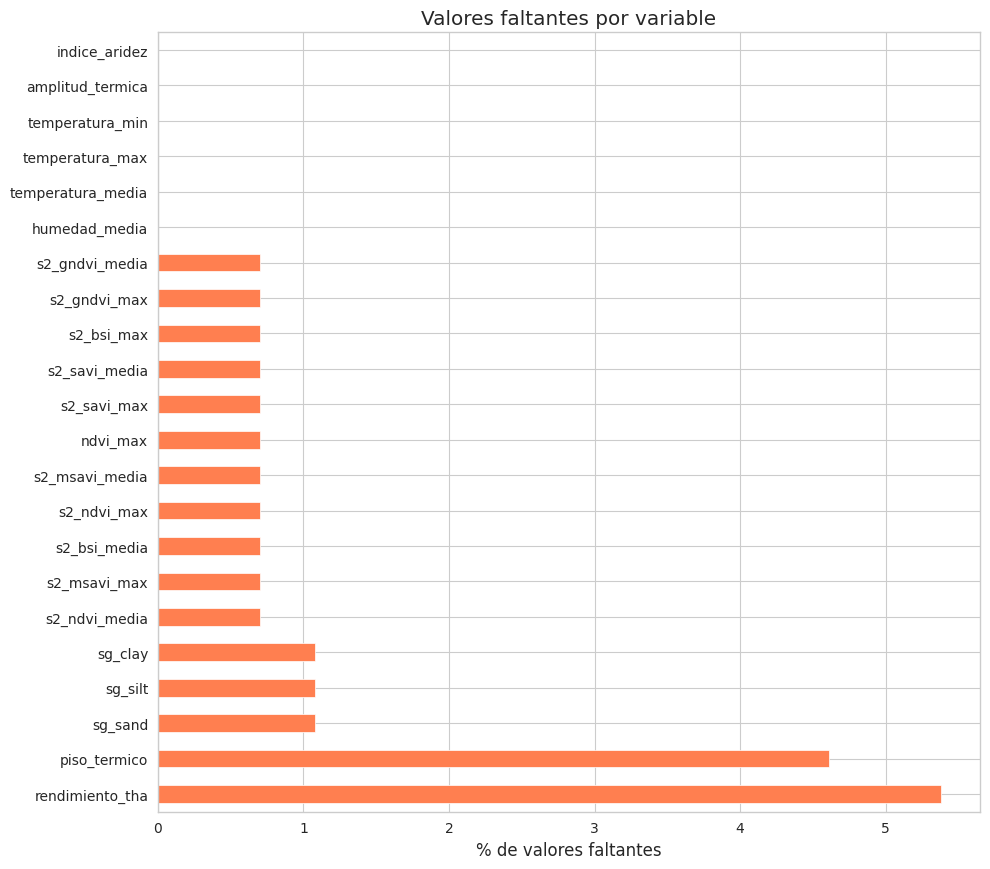

In [51]:
# Visualización de valores faltantes
missing_nonzero = missing_df[missing_df['n_missing'] > 0]
if len(missing_nonzero) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_nonzero)*0.4)))
    missing_nonzero['pct_missing'].plot(kind='barh', ax=ax, color='coral')
    ax.set_xlabel('% de valores faltantes')
    ax.set_title('Valores faltantes por variable')
    plt.tight_layout()
else:
    print("No se encontraron valores faltantes significativos.")

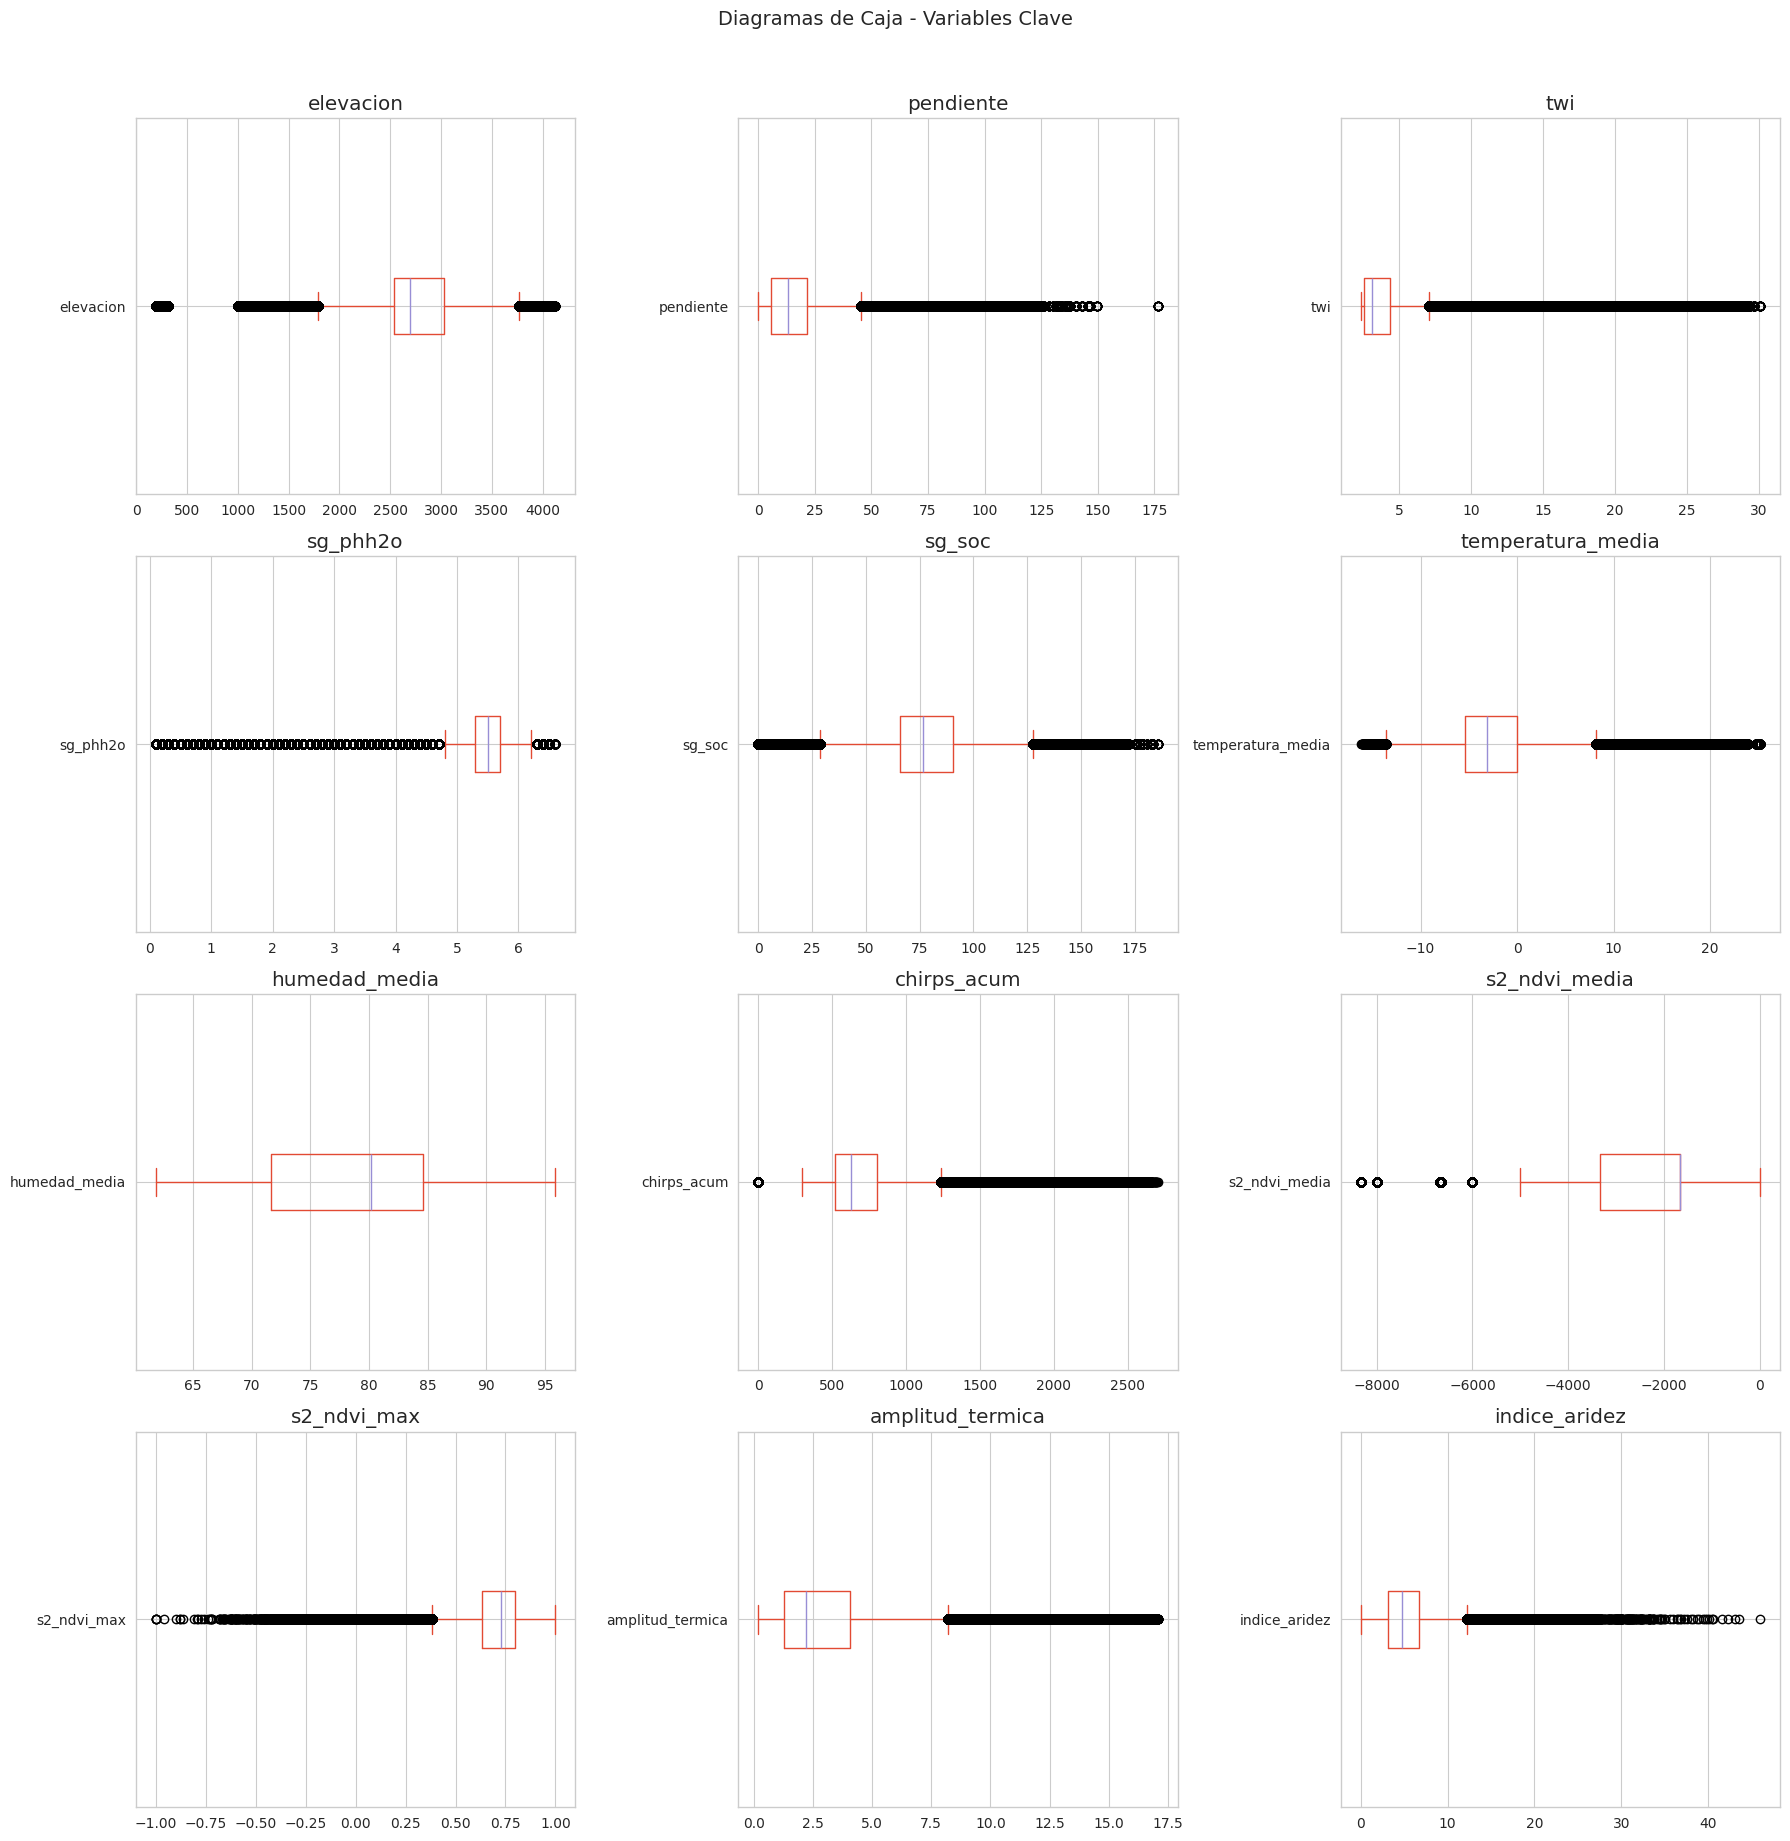

In [52]:
# Detección de outliers con diagramas de caja para variables numéricas clave
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
# Excluir ids y coordenadas
exclude = ['pixel_id', 'cultivo_id']
plot_cols = [c for c in numeric_cols if c not in exclude]

# Seleccionar un subconjunto de variables clave para visualización
key_vars = ['elevacion', 'pendiente', 'twi', 'sg_phh2o', 'sg_soc',
            'temperatura_media', 'humedad_media', 'chirps_acum',
            's2_ndvi_media', 's2_ndvi_max', 'amplitud_termica', 'indice_aridez']
key_vars = [v for v in key_vars if v in df_raw.columns]

fig, axes = plt.subplots(len(key_vars)//3, 3, figsize=(18, len(key_vars)*1.5))
axes = axes.flatten()
for i, col in enumerate(key_vars):
    if i < len(axes):
        df_raw[col].dropna().plot(kind='box', ax=axes[i], vert=False)
        axes[i].set_title(col)
plt.suptitle('Diagramas de Caja - Variables Clave', y=1.02, fontsize=14)
plt.tight_layout()

### 2.6 Análisis de Distribuciones

In [53]:
# Distribución del target - Balance de clases
target_col = 'cultivo_id'
print("Distribución de clases (cultivo_id):")
class_dist = df_raw[target_col].value_counts().sort_index()
class_pct = (df_raw[target_col].value_counts(normalize=True).sort_index() * 100).round(2)

# Mapear nombres de cultivos
inv_catalogo = {v: k for k, v in catalogo.items()}
for cls in class_dist.index:
    name = inv_catalogo.get(cls, f"Clase_{cls}")
    print(f"  {cls} ({name}): {class_dist[cls]:>10,} ({class_pct[cls]:>6.2f}%)")

print(f"\nRatio de desbalance: {class_dist.max() / class_dist.min():.0f}:1")

Distribución de clases (cultivo_id):
  0 (Arroz):     79,971 (  1.51%)
  1 (Cacao):      7,126 (  0.13%)
  2 (Cana Panelera):      6,894 (  0.13%)
  3 (Frijol):    568,210 ( 10.75%)
  4 (Palma):     13,212 (  0.25%)
  5 (Papa):  4,479,531 ( 84.77%)
  6 (Papa Capiro):    129,396 (  2.45%)

Ratio de desbalance: 650:1


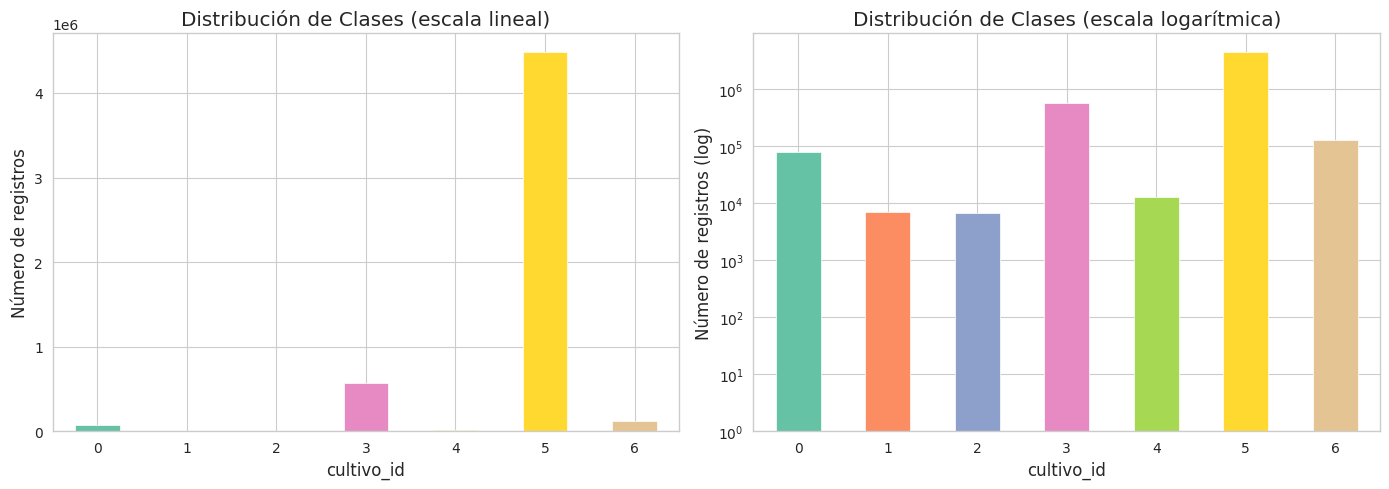

In [54]:
# Visualización del balance de clases
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Barras
class_dist.plot(kind='bar', ax=ax1, color=sns.color_palette("Set2", len(class_dist)))
ax1.set_title('Distribución de Clases (escala lineal)')
ax1.set_xlabel('cultivo_id')
ax1.set_ylabel('Número de registros')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

# Escala logarítmica
class_dist.plot(kind='bar', ax=ax2, color=sns.color_palette("Set2", len(class_dist)), log=True)
ax2.set_title('Distribución de Clases (escala logarítmica)')
ax2.set_xlabel('cultivo_id')
ax2.set_ylabel('Número de registros (log)')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)

plt.tight_layout()

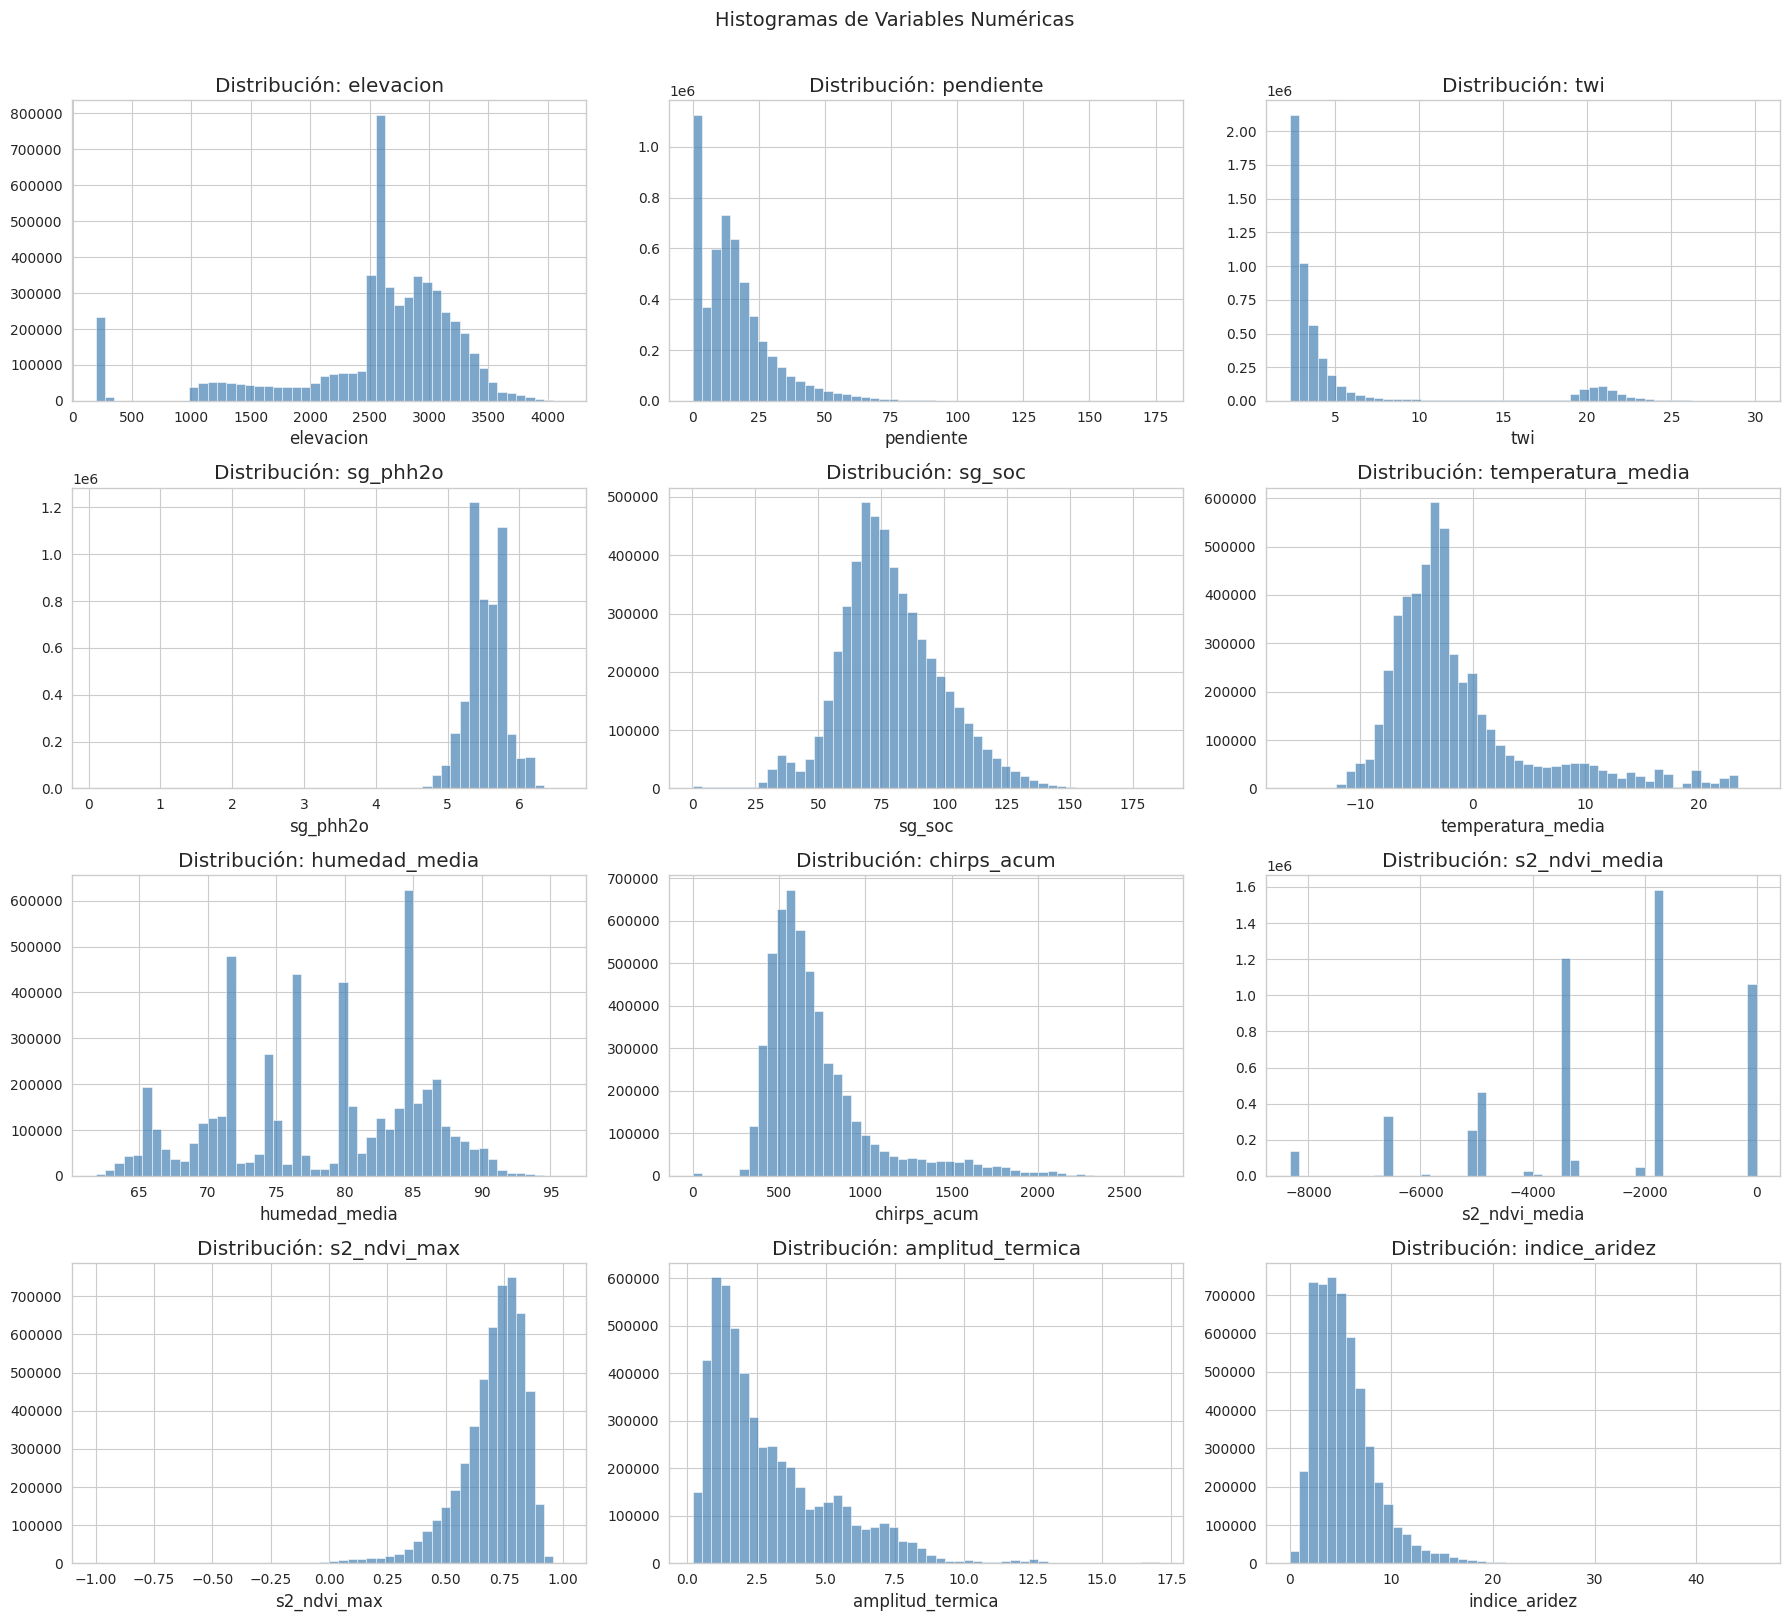

In [55]:
# Histogramas de variables numéricas clave
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()
for i, col in enumerate(key_vars):
    if i < len(axes):
        df_raw[col].dropna().hist(bins=50, ax=axes[i], color='steelblue', alpha=0.7)
        axes[i].set_title(f'Distribución: {col}')
        axes[i].set_xlabel(col)
plt.suptitle('Histogramas de Variables Numéricas', y=1.01, fontsize=14)
plt.tight_layout()

### 2.7 Detección de Patrones - Correlaciones

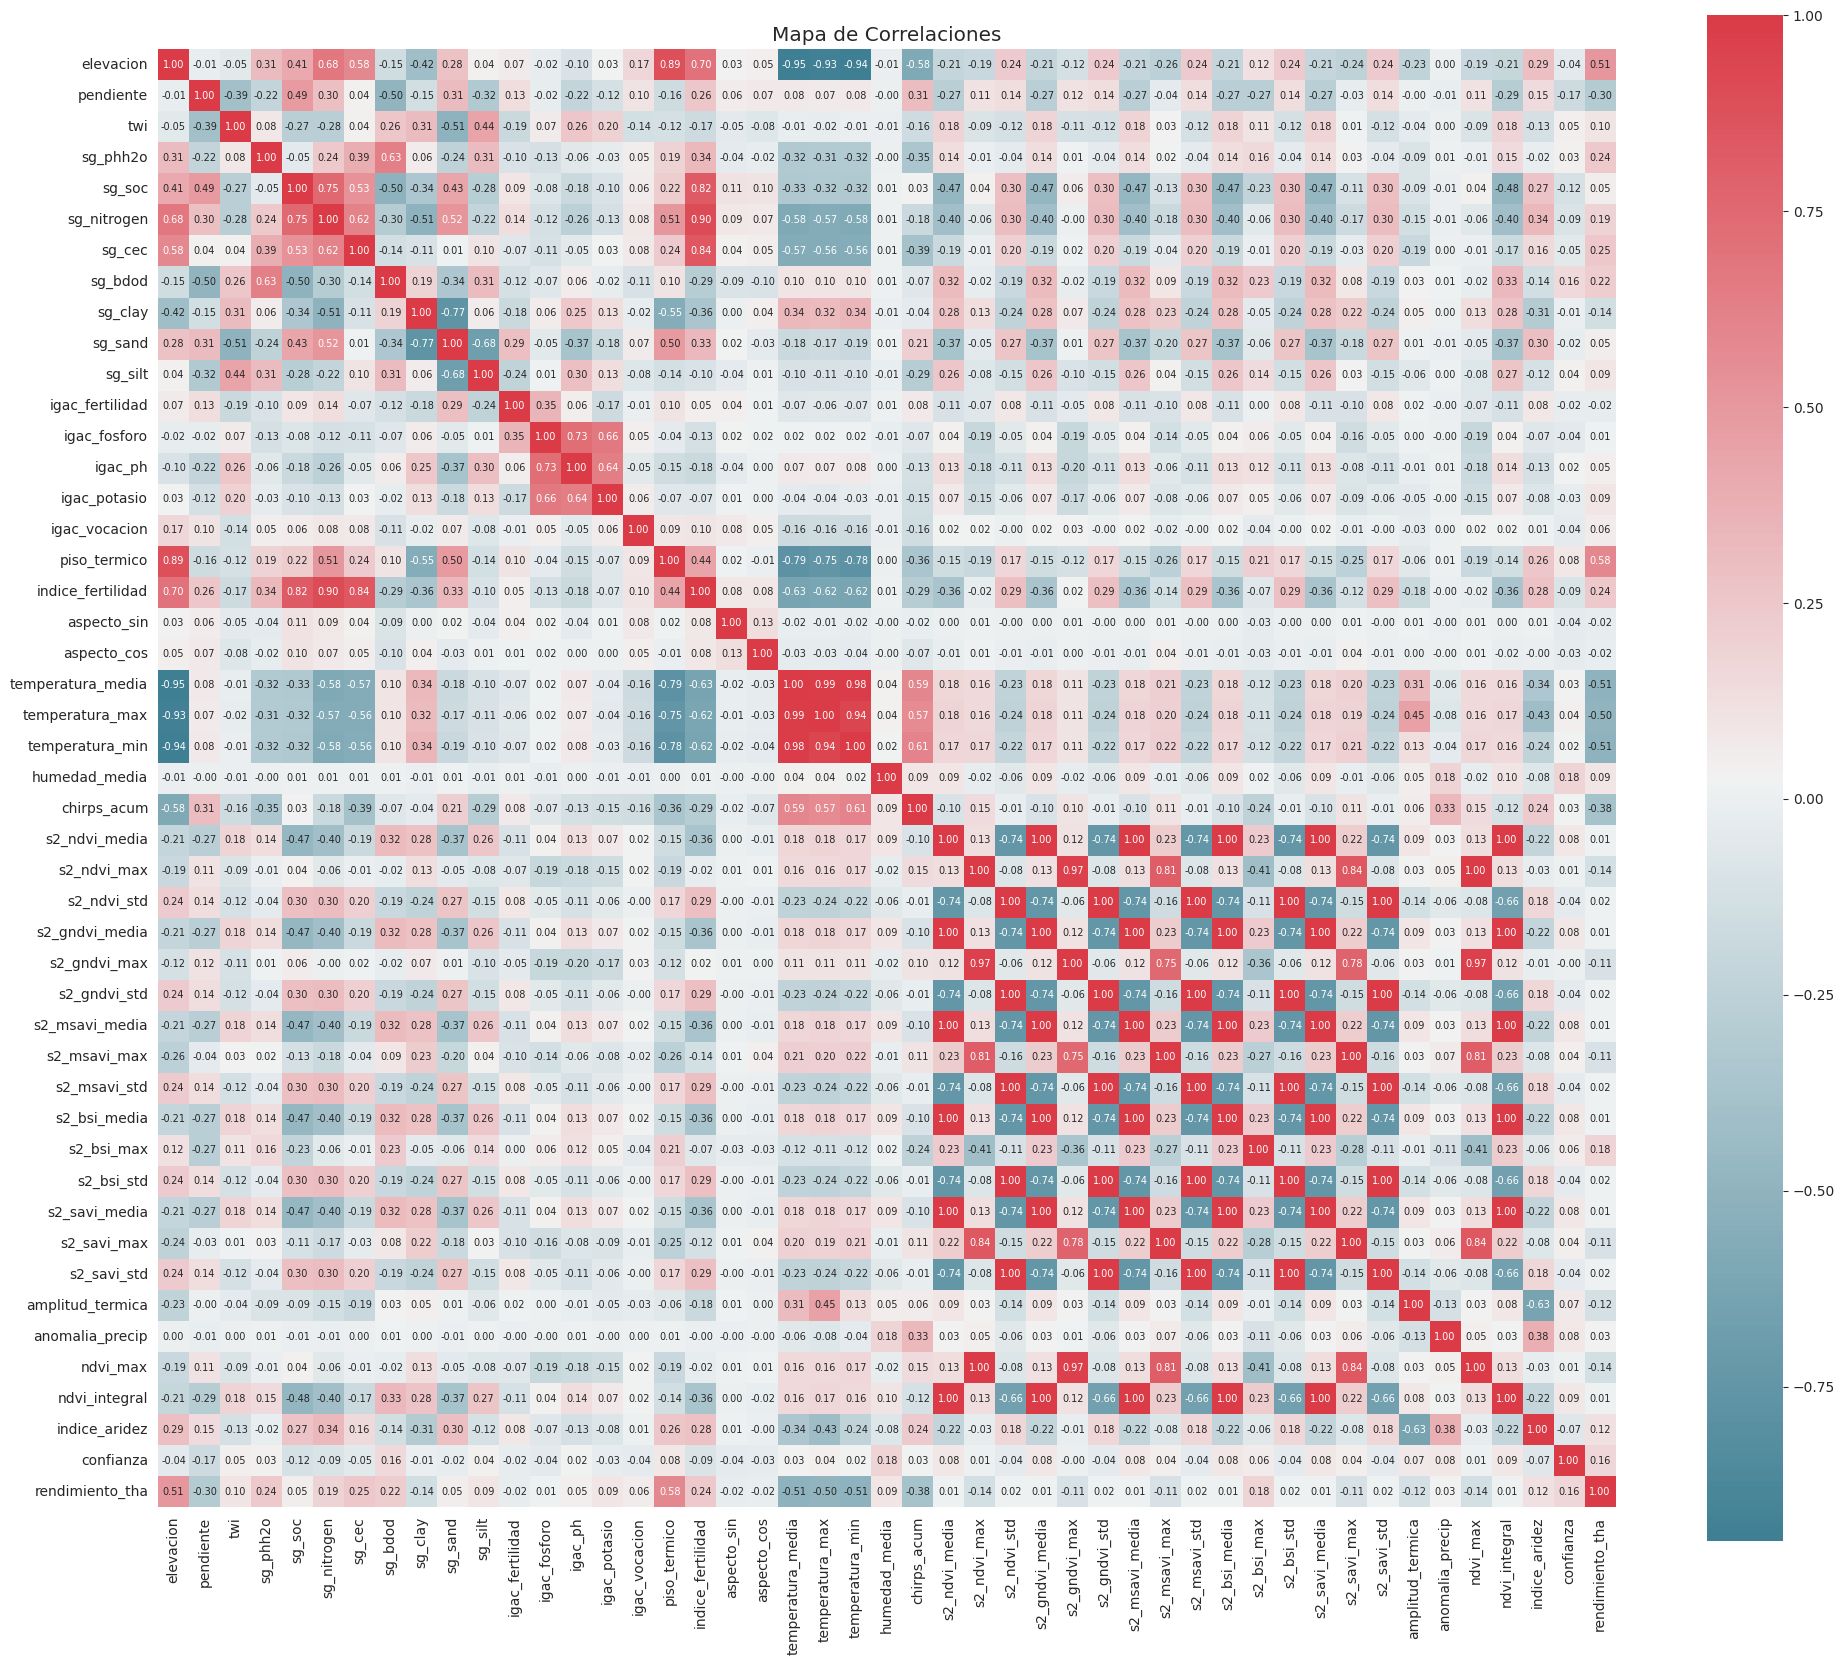

In [56]:
# Mapa de correlación de variables numéricas (sin IDs ni coordenadas)
corr_cols = [c for c in numeric_cols if c not in ['pixel_id', 'x', 'y', 'cultivo_id']]
corr_cols = [c for c in corr_cols if df_raw[c].notna().sum() > 0]  # solo cols con datos
plot_correlation_map(df_raw[corr_cols], figsize=(20, 18))

Top 15 variables más correlacionadas con cultivo_id:
  rendimiento_tha: +0.7168
  elevacion: +0.6600
  piso_termico: +0.6501
  temperatura_min: -0.6420
  temperatura_media: -0.6387
  temperatura_max: -0.6258
  chirps_acum: -0.5061
  sg_cec: +0.4212
  indice_fertilidad: +0.4084
  sg_nitrogen: +0.3189
  sg_phh2o: +0.2823
  pendiente: -0.1929
  sg_soc: +0.1740
  sg_silt: +0.1543
  s2_ndvi_max: -0.1454


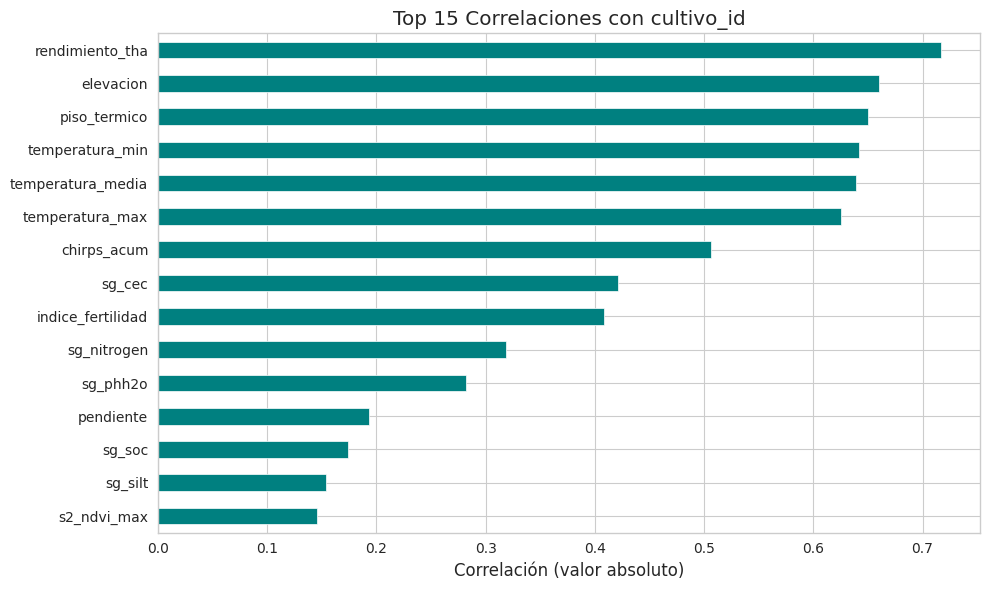

In [57]:
# Correlaciones más fuertes con el target
if target_col in df_raw.columns:
    correlations = df_raw[corr_cols + [target_col]].corr()[target_col].drop(target_col)
    top_corr = correlations.abs().sort_values(ascending=False).head(15)
    print("Top 15 variables más correlacionadas con cultivo_id:")
    for var in top_corr.index:
        print(f"  {var}: {correlations[var]:+.4f}")

    fig, ax = plt.subplots(figsize=(10, 6))
    top_corr.sort_values().plot(kind='barh', ax=ax, color='teal')
    ax.set_title('Top 15 Correlaciones con cultivo_id')
    ax.set_xlabel('Correlación (valor absoluto)')
    plt.tight_layout()

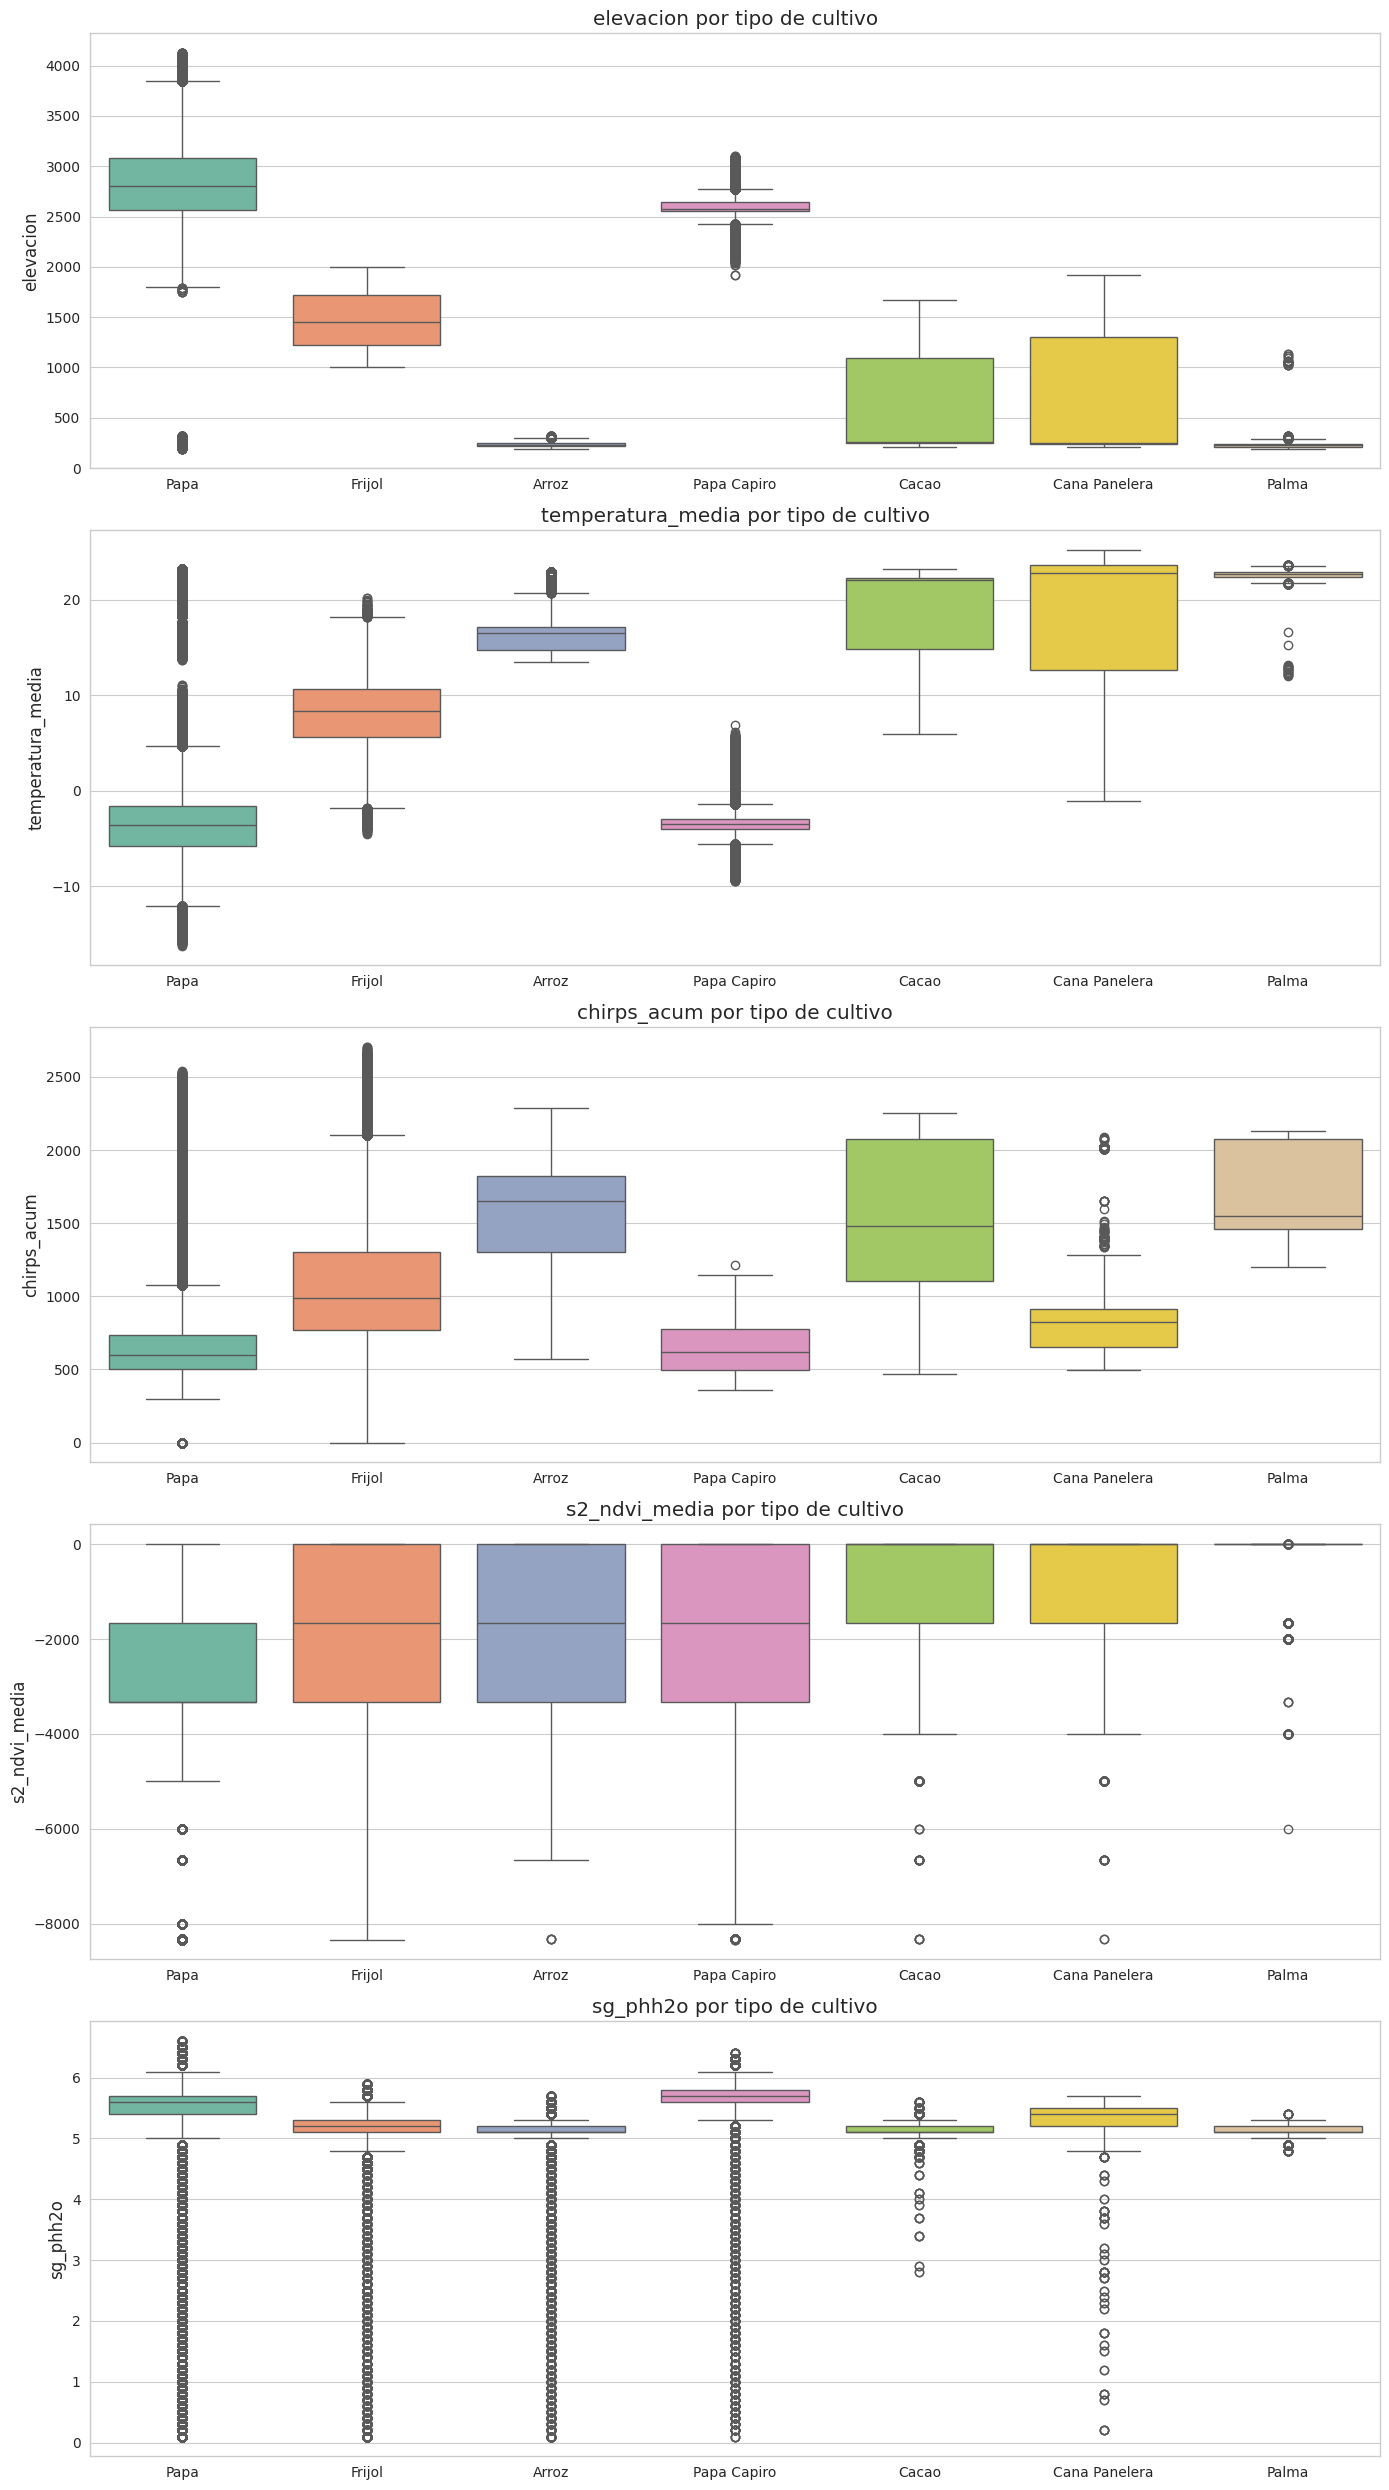

In [58]:
# Distribución de variables clave por cultivo (boxplots)
df_plot = df_raw.copy()
df_plot['cultivo_nombre'] = df_plot['cultivo_id'].map(inv_catalogo)

vars_por_cultivo = ['elevacion', 'temperatura_media', 'chirps_acum', 's2_ndvi_media', 'sg_phh2o']
vars_por_cultivo = [v for v in vars_por_cultivo if v in df_plot.columns]

fig, axes = plt.subplots(len(vars_por_cultivo), 1, figsize=(14, 5*len(vars_por_cultivo)))
for i, var in enumerate(vars_por_cultivo):
    sns.boxplot(data=df_plot, x='cultivo_nombre', y=var, ax=axes[i],
                palette='Set2', hue='cultivo_nombre', legend=False)
    axes[i].set_title(f'{var} por tipo de cultivo')
    axes[i].set_xlabel('')
plt.tight_layout()

### 2.8 Resumen de Comprensión de Datos

A partir del análisis exploratorio podemos concluir:

* **Dimensiones**: El dataset tiene millones de registros con ~49 features + variables target.
* **Desbalance extremo**: La clase Papa domina con ~85% de los registros. Se requiere SMOTE o submuestreo.
* **Valores faltantes**: Algunas variables (rendimiento_tha, s2_*_std) tienen NaNs que deben tratarse.
* **Correlaciones**: Temperatura y elevación están altamente correlacionadas (r≈-0.95). NDVI y GNDVI son casi redundantes.
* **Variables categóricas**: IGAC (fertilidad, pH, fósforo, potasio, vocación) y piso_térmico requieren encoding.
* **Variable temporal**: `semestre` debe codificarse de forma cíclica (sin/cos).

---

# 3. Preparación de los Datos

### 3.1 Estrategia
- Excluir identificadores irrelevantes (`pixel_id`, `x`, `y`)
- Excluir variables redundantes según el análisis estadístico (`temperatura_max`, `temperatura_min`, `s2_savi_*`, `ndvi_max`)
- Codificación cíclica para features temporales (`semestre`)
- Separar variables por tipo (numéricas continuas, ordinales, nominales)
- Construir un preprocesador reutilizable con `Pipeline` y `ColumnTransformer`
- Aplicar SMOTE para balanceo de clases
- Generar particiones train/validation/test (70/15/15 estratificado)

In [59]:
# --- Definición de columnas ---

# Columnas a excluir (metadata, ids, target secundarios)
EXCLUDE_COLS = [
    'pixel_id', 'x', 'y',           # Metadata
    'cultivo', 'confianza', 'fuente', 'rendimiento_tha',  # Target secundarios
    'temperatura_max', 'temperatura_min',  # Redundantes con temperatura_media (r>0.98)
    's2_savi_media', 's2_savi_max', 's2_savi_std',  # Redundantes con MSAVI
    'ndvi_max',                      # Duplicado exacto de s2_ndvi_max
]

# Features temporales para codificación cíclica
CYCLIC_COL = 'semestre'  # se procesará aparte

# Target
TARGET_COL = 'cultivo_id'

print("Columnas excluidas definidas.")

Columnas excluidas definidas.


In [60]:
# --- Codificación cíclica para la variable semestre ---

def encode_semestre_cyclic(df):
    """
    Codificación cíclica del semestre.
    Convierte '2020A' -> (año=2020, sem=0), '2020B' -> (año=2020, sem=1)
    Luego aplica sin/cos para capturar la periodicidad.
    """
    df = df.copy()
    # Extraer año y semestre
    df['year'] = df['semestre'].str[:4].astype(int)
    df['sem'] = df['semestre'].str[4].map({'A': 0, 'B': 1})
    
    # Índice periódico: 2 semestres por año
    period = 2
    angle = 2 * np.pi * df['sem'] / period
    df['semestre_sin'] = np.sin(angle)
    df['semestre_cos'] = np.cos(angle)
    
    # Año normalizado (tendencia temporal)
    df['year_norm'] = (df['year'] - df['year'].min()) / (df['year'].max() - df['year'].min())
    
    # Limpiar columnas intermedias
    df.drop(columns=['semestre', 'year', 'sem'], inplace=True)
    return df

# Aplicar codificación cíclica
df = df_raw.copy()
df = encode_semestre_cyclic(df)
print(f"Columnas después de codificación cíclica: {df.shape[1]}")
print(f"Nuevas columnas: semestre_sin, semestre_cos, year_norm")

# Verificar
df[['semestre_sin', 'semestre_cos', 'year_norm']].describe()

Columnas después de codificación cíclica: 56
Nuevas columnas: semestre_sin, semestre_cos, year_norm


,semestre_sin,semestre_cos,year_norm
count,5284340.0000,5284340.0000,5284340.0000
mean,0.0000,0.0000,0.4323
std,0.0000,1.0000,0.3066
min,0.0000,-1.0000,0.0000
25%,0.0000,-1.0000,0.2000
50%,0.0000,0.0000,0.4000
75%,0.0000,1.0000,0.6000
max,0.0000,1.0000,1.0000


In [61]:
# --- Separar X e y ---

# Features finales
feature_cols = [c for c in df.columns if c not in EXCLUDE_COLS and c != TARGET_COL]
X = df[feature_cols]
y = df[TARGET_COL]

print(f"Features: {X.shape[1]}")
print(f"Registros: {X.shape[0]:,}")
print(f"\nLista de features:\n{feature_cols}")

Features: 42
Registros: 5,284,340

Lista de features:
['elevacion', 'pendiente', 'twi', 'sg_phh2o', 'sg_soc', 'sg_nitrogen', 'sg_cec', 'sg_bdod', 'sg_clay', 'sg_sand', 'sg_silt', 'igac_fertilidad', 'igac_fosforo', 'igac_ph', 'igac_potasio', 'igac_vocacion', 'piso_termico', 'indice_fertilidad', 'aspecto_sin', 'aspecto_cos', 'temperatura_media', 'humedad_media', 'chirps_acum', 's2_ndvi_media', 's2_ndvi_max', 's2_ndvi_std', 's2_gndvi_media', 's2_gndvi_max', 's2_gndvi_std', 's2_msavi_media', 's2_msavi_max', 's2_msavi_std', 's2_bsi_media', 's2_bsi_max', 's2_bsi_std', 'amplitud_termica', 'anomalia_precip', 'ndvi_integral', 'indice_aridez', 'semestre_sin', 'semestre_cos', 'year_norm']


In [62]:
# --- Clasificar features por tipo ---

# Variables ordinales IGAC (ya son numéricas con orden natural)
ordinal_cols = ['igac_ph', 'igac_fosforo', 'igac_potasio', 'igac_fertilidad', 'piso_termico']
ordinal_cols = [c for c in ordinal_cols if c in feature_cols]

# Variable nominal
nominal_cols = ['igac_vocacion']
nominal_cols = [c for c in nominal_cols if c in feature_cols]

# Features cíclicas (ya codificadas)
cyclic_cols = ['semestre_sin', 'semestre_cos', 'year_norm']
cyclic_cols = [c for c in cyclic_cols if c in feature_cols]

# Numéricas continuas (resto)
numeric_continuous = [c for c in feature_cols
                      if c not in ordinal_cols + nominal_cols + cyclic_cols]

print(f"Variables ordinales ({len(ordinal_cols)}): {ordinal_cols}")
print(f"Variables nominales ({len(nominal_cols)}): {nominal_cols}")
print(f"Variables cíclicas ({len(cyclic_cols)}): {cyclic_cols}")
print(f"Variables continuas ({len(numeric_continuous)}): {numeric_continuous}")

Variables ordinales (5): ['igac_ph', 'igac_fosforo', 'igac_potasio', 'igac_fertilidad', 'piso_termico']
Variables nominales (1): ['igac_vocacion']
Variables cíclicas (3): ['semestre_sin', 'semestre_cos', 'year_norm']
Variables continuas (33): ['elevacion', 'pendiente', 'twi', 'sg_phh2o', 'sg_soc', 'sg_nitrogen', 'sg_cec', 'sg_bdod', 'sg_clay', 'sg_sand', 'sg_silt', 'indice_fertilidad', 'aspecto_sin', 'aspecto_cos', 'temperatura_media', 'humedad_media', 'chirps_acum', 's2_ndvi_media', 's2_ndvi_max', 's2_ndvi_std', 's2_gndvi_media', 's2_gndvi_max', 's2_gndvi_std', 's2_msavi_media', 's2_msavi_max', 's2_msavi_std', 's2_bsi_media', 's2_bsi_max', 's2_bsi_std', 'amplitud_termica', 'anomalia_precip', 'ndvi_integral', 'indice_aridez']


In [63]:
# --- Partición de datos: 70% train, 15% validación, 15% prueba ---

# Para manejar el volumen, tomamos una muestra estratificada si es necesario
# Si el dataset es muy grande, usaremos un subconjunto para modelado
MAX_SAMPLES = 500_000  # Limitar para viabilidad computacional

if len(X) > MAX_SAMPLES:
    print(f"Dataset muy grande ({len(X):,}). Tomando muestra estratificada de {MAX_SAMPLES:,}...")
    X_sample, _, y_sample, _ = train_test_split(
        X, y, train_size=MAX_SAMPLES, stratify=y, random_state=42
    )
    X = X_sample
    y = y_sample
    print(f"Muestra resultante: {X.shape[0]:,} registros")

# Split 1: Separar test (15%)
X_train_valid, X_test, y_train_valid, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

# Split 2: Separar validación (15% del total = 15/85 ≈ 17.6% del restante)
valid_size = 0.15 / 0.85
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_valid, y_train_valid, test_size=valid_size,
    stratify=y_train_valid, random_state=42
)

print(f"\nParticiones:")
print(f"  Entrenamiento: {X_train.shape[0]:,} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Validación:    {X_valid.shape[0]:,} ({X_valid.shape[0]/len(X)*100:.1f}%)")
print(f"  Prueba:        {X_test.shape[0]:,} ({X_test.shape[0]/len(X)*100:.1f}%)")

Dataset muy grande (5,284,340). Tomando muestra estratificada de 500,000...
Muestra resultante: 500,000 registros

Particiones:
  Entrenamiento: 350,000 (70.0%)
  Validación:    75,000 (15.0%)
  Prueba:        75,000 (15.0%)


In [64]:
# --- Preprocesador con ColumnTransformer ---

# Pipeline para variables continuas: imputación + escalamiento
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline para variables ordinales: imputación (ya son numéricas)
ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# Pipeline para variables nominales: imputación + one-hot
nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_continuous),
    ('ord', ordinal_transformer, ordinal_cols),
    ('nom', nominal_transformer, nominal_cols),
    ('cyclic', 'passthrough', cyclic_cols)
], remainder='drop')

print("Preprocesador construido:")
print(preprocessor)

Preprocesador construido:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['elevacion', 'pendiente', 'twi', 'sg_phh2o',
                                  'sg_soc', 'sg_nitrogen', 'sg_cec', 'sg_bdod',
                                  'sg_clay', 'sg_sand', 'sg_silt',
                                  'indice_fertilidad', 'aspecto_sin',
                                  'aspecto_cos', 'temperatura_media',
                                  'humedad_media', 'chirps_acum',
                                  's2_ndvi...
                                                  SimpleImputer(strategy='most_frequent'))]),
                                 ['igac_ph', 'igac_fosforo', 'igac_potasio',
                                  'igac_fertilidad', 'piso

In [65]:
# --- Aplicar preprocesamiento y SMOTE al conjunto de entrenamiento ---

# Ajustar el preprocesador con datos de entrenamiento y transformar
X_train_prep = preprocessor.fit_transform(X_train)
X_valid_prep = preprocessor.transform(X_valid)
X_test_prep = preprocessor.transform(X_test)

print(f"Datos preprocesados:")
print(f"  X_train: {X_train_prep.shape}")
print(f"  X_valid: {X_valid_prep.shape}")
print(f"  X_test:  {X_test_prep.shape}")

# Obtener nombres de features después del preprocesamiento
feature_names = list(numeric_continuous) + list(ordinal_cols)
if nominal_cols:
    ohe = preprocessor.named_transformers_['nom'].named_steps['encoder']
    nominal_encoded = list(ohe.get_feature_names_out(nominal_cols))
    feature_names += nominal_encoded
feature_names += cyclic_cols
print(f"\nTotal features después de preprocesamiento: {len(feature_names)}")

Datos preprocesados:
  X_train: (350000, 49)
  X_valid: (75000, 49)
  X_test:  (75000, 49)

Total features después de preprocesamiento: 49


In [66]:
# --- SMOTE para balanceo de clases ---

print("Distribución ANTES de SMOTE:")
print(pd.Series(y_train).value_counts().sort_index())

# Aplicar SMOTE solo al conjunto de entrenamiento
smote = SMOTE(random_state=42, sampling_strategy='auto', k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_prep, y_train)

print(f"\nDistribución DESPUÉS de SMOTE:")
print(pd.Series(y_train_smote).value_counts().sort_index())
print(f"\nShape después de SMOTE: {X_train_smote.shape}")

Distribución ANTES de SMOTE:
cultivo_id
0      5297
1       472
2       456
3     37634
4       875
5    296695
6      8571
Name: count, dtype: int64

Distribución DESPUÉS de SMOTE:
cultivo_id
0    296695
1    296695
2    296695
3    296695
4    296695
5    296695
6    296695
Name: count, dtype: int64

Shape después de SMOTE: (2076865, 49)


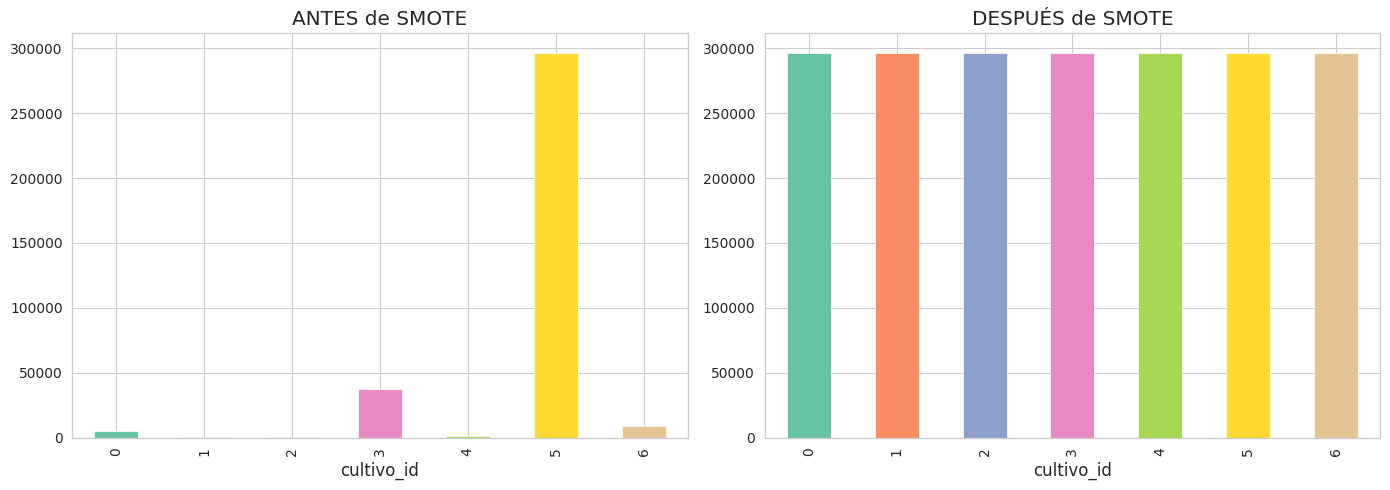

In [67]:
# Visualización antes y después de SMOTE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

pd.Series(y_train).value_counts().sort_index().plot(
    kind='bar', ax=ax1, color=sns.color_palette("Set2", 7)
)
ax1.set_title('ANTES de SMOTE')
ax1.set_xlabel('cultivo_id')

pd.Series(y_train_smote).value_counts().sort_index().plot(
    kind='bar', ax=ax2, color=sns.color_palette("Set2", 7)
)
ax2.set_title('DESPUÉS de SMOTE')
ax2.set_xlabel('cultivo_id')

plt.tight_layout()

### 3.2 Resultado de la Preparación

- Se excluyeron variables de metadata, redundantes y target secundarios.
- La variable `semestre` fue codificada con **codificación cíclica** (sin/cos) para capturar la estacionalidad.
- Se construyó un `ColumnTransformer` con pipelines diferenciados para continuas, ordinales y nominales.
- Se aplicó **SMOTE** para balancear las clases en entrenamiento.
- Particiones: **70% entrenamiento, 15% validación, 15% prueba** estratificadas.

---

# 4. Modelamiento

### 4.1 Análisis de Componentes Principales (PCA)

Aplicamos PCA para:
- Reducir dimensionalidad
- Visualizar la separabilidad de las clases en 2D/3D
- Determinar cuántos componentes explican la mayoría de la varianza

In [68]:
# --- PCA: Análisis de varianza explicada ---

# Aplicar PCA con todos los componentes para analizar varianza
pca_full = PCA(random_state=42)
pca_full.fit(X_train_smote)

# Varianza explicada
explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Encontrar componentes para 90% y 95% de varianza
n_90 = np.argmax(cumulative_var >= 0.90) + 1
n_95 = np.argmax(cumulative_var >= 0.95) + 1

print(f"Número de componentes para 90% varianza: {n_90}")
print(f"Número de componentes para 95% varianza: {n_95}")
print(f"Total de features originales: {X_train_smote.shape[1]}")

Número de componentes para 90% varianza: 13
Número de componentes para 95% varianza: 17
Total de features originales: 49


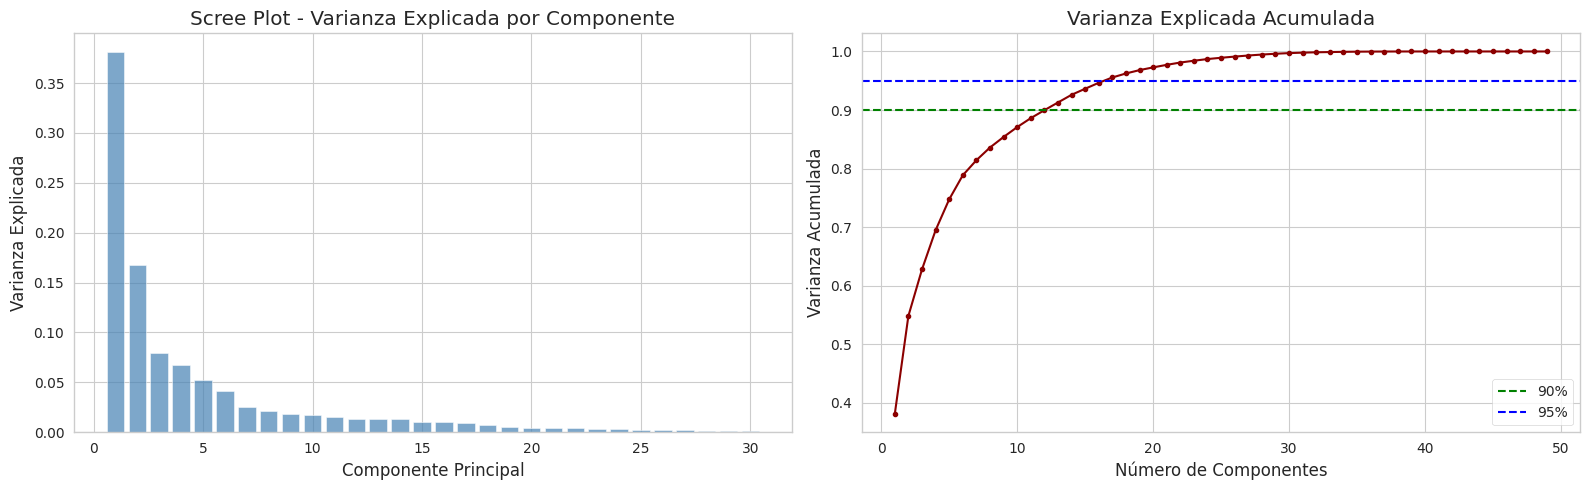

In [69]:
# Scree plot y varianza acumulada
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Scree plot
n_show = min(30, len(explained_var))
ax1.bar(range(1, n_show+1), explained_var[:n_show], alpha=0.7, color='steelblue')
ax1.set_xlabel('Componente Principal')
ax1.set_ylabel('Varianza Explicada')
ax1.set_title('Scree Plot - Varianza Explicada por Componente')

# Varianza acumulada
ax2.plot(range(1, len(cumulative_var)+1), cumulative_var, '-o', markersize=3, color='darkred')
ax2.axhline(y=0.90, color='green', linestyle='--', label='90%')
ax2.axhline(y=0.95, color='blue', linestyle='--', label='95%')
ax2.set_xlabel('Número de Componentes')
ax2.set_ylabel('Varianza Acumulada')
ax2.set_title('Varianza Explicada Acumulada')
ax2.legend()

plt.tight_layout()

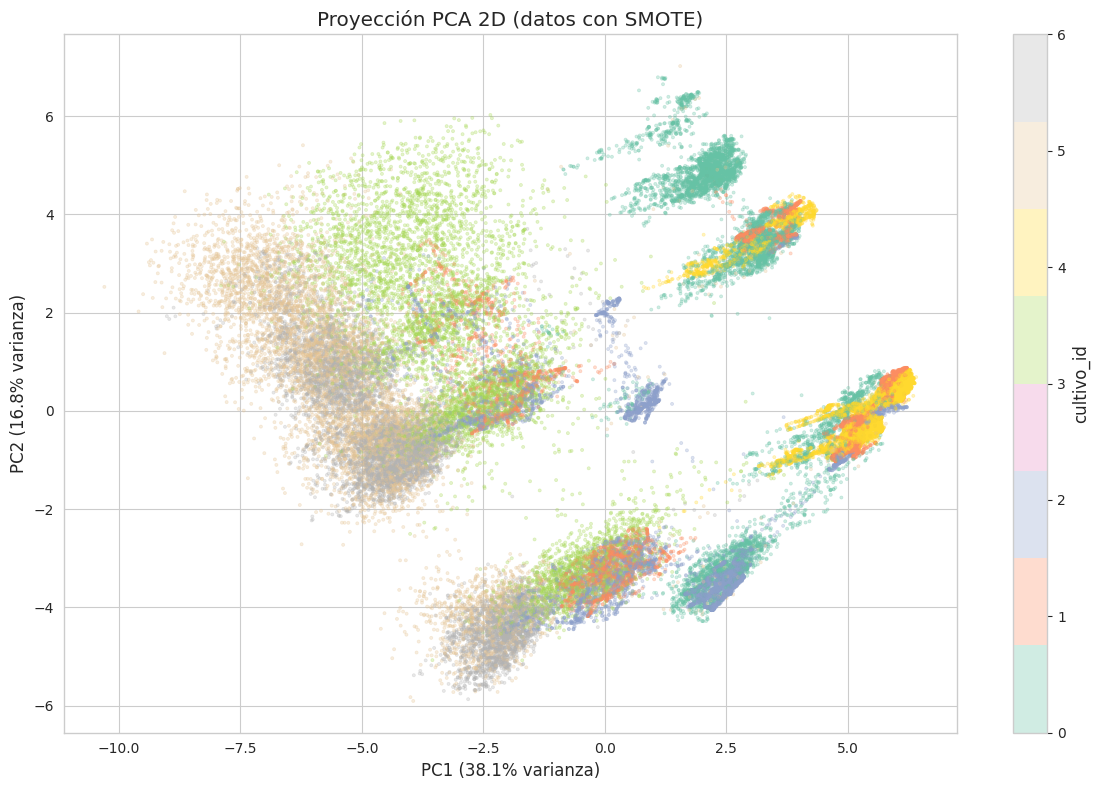

In [70]:
# Visualización PCA en 2D (coloreado por cultivo)
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_train_smote)

# Muestrear para visualización
n_viz = min(50_000, len(X_pca_2d))
idx_viz = np.random.choice(len(X_pca_2d), n_viz, replace=False)

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(
    X_pca_2d[idx_viz, 0], X_pca_2d[idx_viz, 1],
    c=y_train_smote.iloc[idx_viz] if hasattr(y_train_smote, 'iloc') else y_train_smote[idx_viz],
    cmap='Set2', alpha=0.3, s=5
)
ax.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({explained_var[1]*100:.1f}% varianza)')
ax.set_title('Proyección PCA 2D (datos con SMOTE)')
plt.colorbar(scatter, label='cultivo_id')
plt.tight_layout()

### 4.2 Modelos Base — Evaluación Inicial

Evaluamos modelos con sesgos y capacidades complementarias:
- **LogisticRegression**: línea base interpretable con regularización
- **RandomForest**: ensamble de árboles robusto al ruido
- **XGBoost**: gradient boosting de alto desempeño
- **KNeighbors**: referencia basada en proximidad

In [71]:
# --- Función de evaluación de modelos ---

def evaluate_model(name, model, X_tr, y_tr, X_va, y_va):
    """Entrena un modelo y calcula métricas en validación."""
    model.fit(X_tr, y_tr)
    preds = model.predict(X_va)
    
    # Probabilidades (si disponibles)
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X_va)
    elif hasattr(model, 'decision_function'):
        proba = model.decision_function(X_va)
    else:
        proba = None
    
    # Métricas
    metrics = {
        'model': name,
        'accuracy': accuracy_score(y_va, preds),
        'precision_macro': precision_score(y_va, preds, average='macro', zero_division=0),
        'recall_macro': recall_score(y_va, preds, average='macro', zero_division=0),
        'f1_macro': f1_score(y_va, preds, average='macro', zero_division=0),
    }
    
    # ROC-AUC multiclase
    if proba is not None:
        classes = np.unique(y_va)
        y_va_bin = label_binarize(y_va, classes=classes)
        if proba.ndim == 2 and proba.shape[1] == len(classes):
            metrics['roc_auc_ovr'] = roc_auc_score(y_va_bin, proba, multi_class='ovr', average='macro')
    else:
        metrics['roc_auc_ovr'] = np.nan
    
    return metrics, model, preds, proba

print("Función de evaluación definida.")

Función de evaluación definida.


In [72]:
# --- Entrenar modelos base con datos SMOTE ---

n_classes = len(np.unique(y_train_smote))

models = {
    'LogisticRegression': LogisticRegression(
        max_iter=1000, class_weight='balanced',
        solver='lbfgs', multi_class='multinomial', random_state=42
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=200, max_depth=15,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        objective='multi:softprob', num_class=n_classes,
        eval_metric='mlogloss', random_state=42,
        n_jobs=-1, tree_method=XGB_TREE_METHOD, device=XGB_DEVICE
    )
}

results = []
trained_models = {}

for name, model in models.items():
    print(f"Entrenando {name}...")
    metrics, trained, preds, proba = evaluate_model(
        name, model, X_train_smote, y_train_smote, X_valid_prep, y_valid
    )
    results.append(metrics)
    trained_models[name] = trained
    print(f"  F1_macro={metrics['f1_macro']:.4f}, Accuracy={metrics['accuracy']:.4f}, ROC-AUC={metrics['roc_auc_ovr']:.4f}")

print("\nModelos base entrenados.")

Entrenando LogisticRegression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  F1_macro=0.8282, Accuracy=0.9663, ROC-AUC=0.9988
Entrenando RandomForest...
  F1_macro=0.9127, Accuracy=0.9835, ROC-AUC=0.9997
Entrenando XGBoost...
  F1_macro=0.9550, Accuracy=0.9949, ROC-AUC=0.9999

Modelos base entrenados.


In [75]:
# --- Comparación de modelos base ---

metrics_df = pd.DataFrame(results).set_index('model').sort_values('f1_macro', ascending=False)
print("Comparación de modelos base (ordenados por F1 macro):")
metrics_df

Comparación de modelos base (ordenados por F1 macro):


,accuracy,precision_macro,recall_macro,f1_macro,roc_auc_ovr
model,,,,,
XGBoost,0.9949,0.9427,0.9699,0.9550,0.9999
RandomForest,0.9835,0.8808,0.9637,0.9127,0.9997
LogisticRegression,0.9663,0.7815,0.9186,0.8282,0.9988


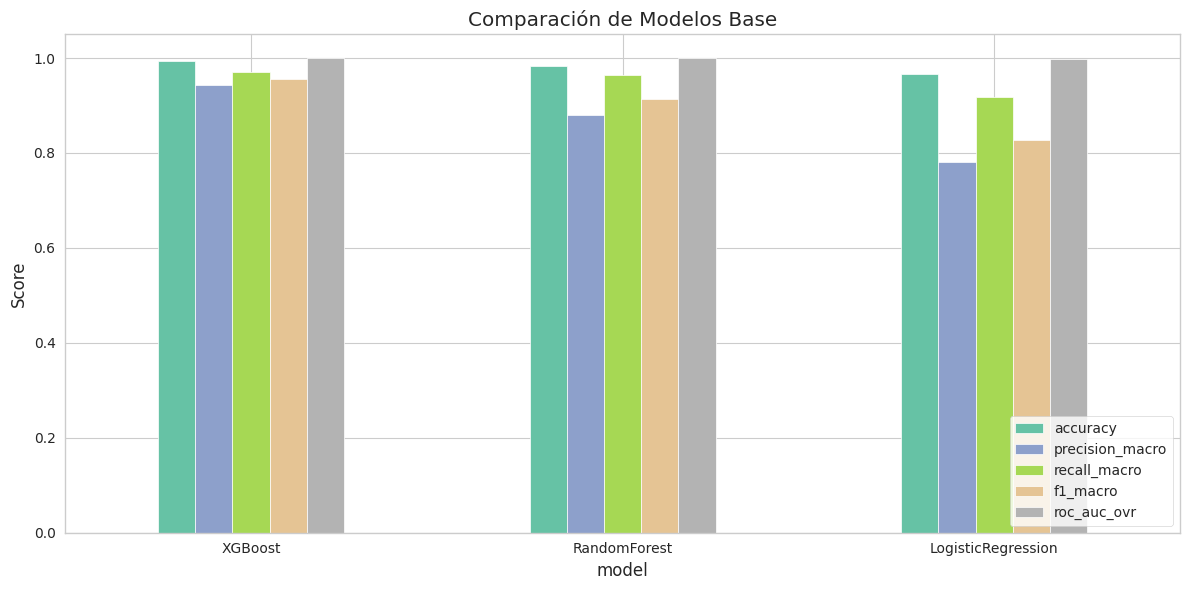

In [76]:
# Visualización comparativa
fig, ax = plt.subplots(figsize=(12, 6))
metrics_df[['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'roc_auc_ovr']].plot(
    kind='bar', ax=ax, colormap='Set2'
)
ax.set_title('Comparación de Modelos Base')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()

### 4.3 Regularización — LogisticRegression con L1 y L2

Evaluamos el efecto de la regularización L1 (Lasso) y L2 (Ridge) en la regresión logística. La regularización L1 puede inducir selección automática de variables.

In [ ]:
# --- Regularización L1 y L2 ---

C_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
reg_results = []

for penalty in ['l1', 'l2']:
    for C in C_values:
        solver = 'saga' if penalty == 'l1' else 'lbfgs'
        lr = LogisticRegression(
            penalty=penalty, C=C, solver=solver,
            max_iter=2000, class_weight='balanced',
            multi_class='multinomial', random_state=42
        )
        lr.fit(X_train_smote, y_train_smote)
        preds = lr.predict(X_valid_prep)
        f1 = f1_score(y_valid, preds, average='macro', zero_division=0)
        
        # Número de coeficientes no neros (promedio por clase)
        n_nonzero = np.mean([np.sum(c != 0) for c in lr.coef_])
        
        reg_results.append({
            'penalty': penalty.upper(), 'C': C, 'f1_macro': f1,
            'n_nonzero_coefs': n_nonzero
        })
        print(f"  {penalty.upper()} C={C:>6} → F1={f1:.4f} | coefs no-zero={n_nonzero:.0f}/{X_train_smote.shape[1]}")

reg_df = pd.DataFrame(reg_results)
print("\nResultados de regularización:")
reg_df

  L1 C= 0.001 → F1=0.7805 | coefs no-zero=17/49


In [ ]:
# Visualización de regularización
fig, ax = plt.subplots(figsize=(10, 5))
for penalty in ['L1', 'L2']:
    subset = reg_df[reg_df['penalty'] == penalty]
    ax.plot(subset['C'], subset['f1_macro'], '-o', label=f'{penalty}', markersize=8)
ax.set_xscale('log')
ax.set_xlabel('C (inversa de regularización)')
ax.set_ylabel('F1 Macro')
ax.set_title('Efecto de la Regularización en LogisticRegression')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

### 4.4 XGBoost — Modelo Principal

XGBoost es nuestro modelo principal por su capacidad para manejar:
- Relaciones no lineales
- Variables de diferentes escalas
- Clases desbalanceadas
- Alta dimensionalidad

In [77]:
# --- XGBoost con early stopping ---

# Preparar conjuntos para evaluación
eval_set = [
    (X_train_smote, y_train_smote),
    (X_valid_prep, y_valid)
]

xgb_model = XGBClassifier(
    n_estimators=1000,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=n_classes,
    eval_metric='mlogloss',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
    tree_method=XGB_TREE_METHOD, device=XGB_DEVICE
)

xgb_model.fit(
    X_train_smote, y_train_smote,
    eval_set=eval_set,
    verbose=50
)

print(f"\nMejor iteración: {xgb_model.best_iteration}")
print(f"Mejor score: {xgb_model.best_score:.4f}")

[0]	validation_0-mlogloss:1.78216	validation_1-mlogloss:1.77899
[50]	validation_0-mlogloss:0.15047	validation_1-mlogloss:0.15756
[100]	validation_0-mlogloss:0.03301	validation_1-mlogloss:0.04845
[150]	validation_0-mlogloss:0.01344	validation_1-mlogloss:0.03041
[200]	validation_0-mlogloss:0.00687	validation_1-mlogloss:0.02273
[250]	validation_0-mlogloss:0.00391	validation_1-mlogloss:0.01787
[300]	validation_0-mlogloss:0.00246	validation_1-mlogloss:0.01518
[350]	validation_0-mlogloss:0.00165	validation_1-mlogloss:0.01357
[400]	validation_0-mlogloss:0.00118	validation_1-mlogloss:0.01258
[450]	validation_0-mlogloss:0.00088	validation_1-mlogloss:0.01192
[500]	validation_0-mlogloss:0.00069	validation_1-mlogloss:0.01154
[550]	validation_0-mlogloss:0.00054	validation_1-mlogloss:0.01127
[600]	validation_0-mlogloss:0.00043	validation_1-mlogloss:0.01105
[650]	validation_0-mlogloss:0.00035	validation_1-mlogloss:0.01093
[700]	validation_0-mlogloss:0.00029	validation_1-mlogloss:0.01083
[750]	validat

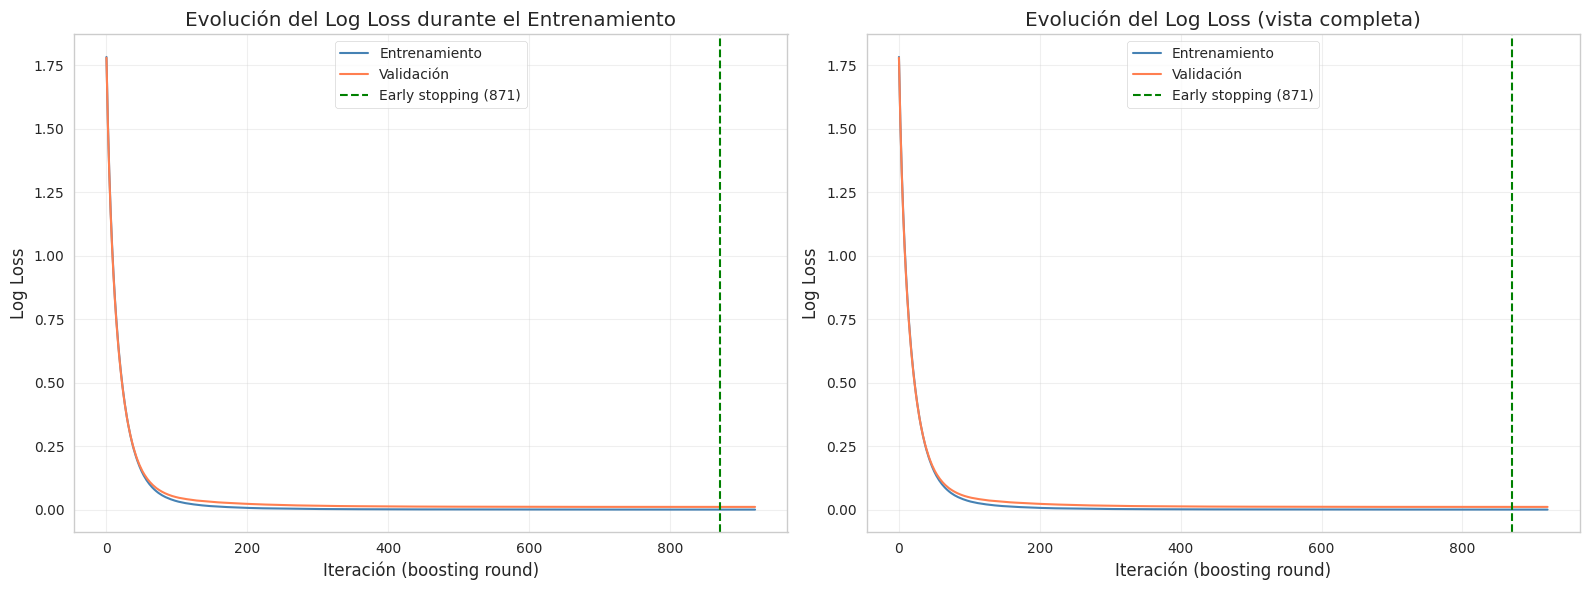

In [78]:
# --- Visualización del Proceso de Entrenamiento ---
#
# Graficamos la evolución de la función de pérdida (loss) y la precisión (accuracy)
# durante el entrenamiento. Esto permite:
# - Identificar si hay **overfitting**: cuando la pérdida de entrenamiento disminuye
#   pero la de validación aumenta
# - Verificar que el modelo **converge**: las curvas se estabilizan
# - Confirmar que el **early stopping** funcionó correctamente

results_xgb = xgb_model.evals_result()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Curva de pérdida (log loss)
epochs = len(results_xgb['validation_0']['mlogloss'])
x_axis = range(0, epochs)

ax1.plot(x_axis, results_xgb['validation_0']['mlogloss'], label='Entrenamiento', color='steelblue')
ax1.plot(x_axis, results_xgb['validation_1']['mlogloss'], label='Validación', color='coral')
ax1.axvline(x=xgb_model.best_iteration, color='green', linestyle='--', label=f'Early stopping ({xgb_model.best_iteration})')
ax1.set_xlabel('Iteración (boosting round)')
ax1.set_ylabel('Log Loss')
ax1.set_title('Evolución del Log Loss durante el Entrenamiento')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Calcular accuracy por iteración a partir de las predicciones
# Nota: XGBoost guarda merror para multi-class
if 'merror' in results_xgb['validation_0']:
    ax2.plot(x_axis, [1-e for e in results_xgb['validation_0']['merror']], label='Entrenamiento', color='steelblue')
    ax2.plot(x_axis, [1-e for e in results_xgb['validation_1']['merror']], label='Validación', color='coral')
    ax2.axvline(x=xgb_model.best_iteration, color='green', linestyle='--', label=f'Early stopping ({xgb_model.best_iteration})')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Evolución del Accuracy durante el Entrenamiento')
else:
    ax2.plot(x_axis, results_xgb['validation_0']['mlogloss'], label='Entrenamiento', color='steelblue')
    ax2.plot(x_axis, results_xgb['validation_1']['mlogloss'], label='Validación', color='coral')
    ax2.axvline(x=xgb_model.best_iteration, color='green', linestyle='--', label=f'Early stopping ({xgb_model.best_iteration})')
    ax2.set_ylabel('Log Loss')
    ax2.set_title('Evolución del Log Loss (vista completa)')

ax2.set_xlabel('Iteración (boosting round)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()

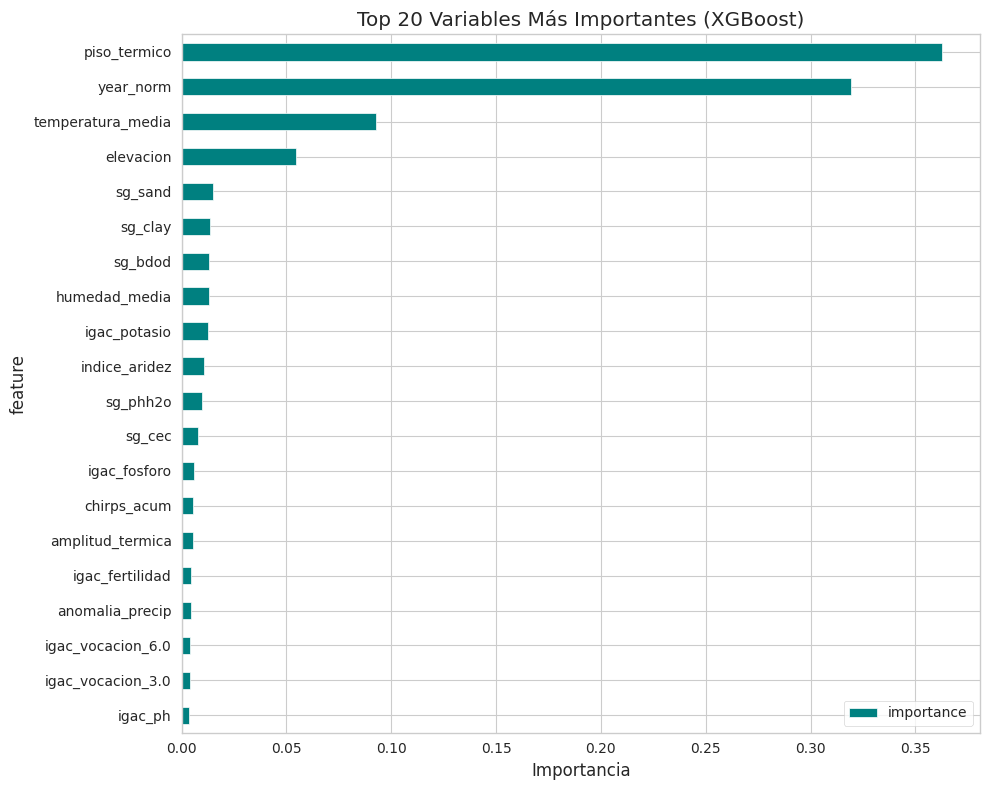

In [79]:
# --- Importancia de variables (XGBoost) ---

importance = xgb_model.feature_importances_
feat_imp = pd.DataFrame({
    'feature': feature_names[:len(importance)],
    'importance': importance
}).sort_values('importance', ascending=False)

# Top 20 features
top_n = 20
fig, ax = plt.subplots(figsize=(10, 8))
feat_imp.head(top_n).sort_values('importance').plot(
    kind='barh', x='feature', y='importance', ax=ax, color='teal'
)
ax.set_title(f'Top {top_n} Variables Más Importantes (XGBoost)')
ax.set_xlabel('Importancia')
plt.tight_layout()

### 4.5 Optimización Bayesiana con Optuna

Optuna realiza una búsqueda inteligente del espacio de hiperparámetros usando optimización bayesiana (TPE), mucho más eficiente que Grid Search.

In [80]:
# --- Optimización bayesiana con Optuna para XGBoost ---

def objective(trial):
    """Función objetivo para Optuna."""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 800),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
        'objective': 'multi:softprob',
        'num_class': n_classes,
        'eval_metric': 'mlogloss',
        'random_state': 42,
        'n_jobs': -1,
        'tree_method': XGB_TREE_METHOD, 'device': XGB_DEVICE
    }
    
    model = XGBClassifier(**params)
    model.fit(
        X_train_smote, y_train_smote,
        eval_set=[(X_valid_prep, y_valid)],
        verbose=False
    )
    preds = model.predict(X_valid_prep)
    f1 = f1_score(y_valid, preds, average='macro', zero_division=0)
    return f1

# Ejecutar optimización
N_TRIALS = 30  # Número de combinaciones a probar
study = optuna.create_study(direction='maximize', study_name='xgb_optuna')
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nMejor F1 macro: {study.best_value:.4f}")
print(f"Mejores parámetros:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/30 [00:00<?, ?it/s]


Mejor F1 macro: 0.9576
Mejores parámetros:
  n_estimators: 255
  max_depth: 8
  learning_rate: 0.2394087469801872
  subsample: 0.8404836215268459
  colsample_bytree: 0.9593599016718634
  min_child_weight: 6
  gamma: 0.7696248462524024
  reg_alpha: 0.11792124007637045
  reg_lambda: 3.4731791507494734


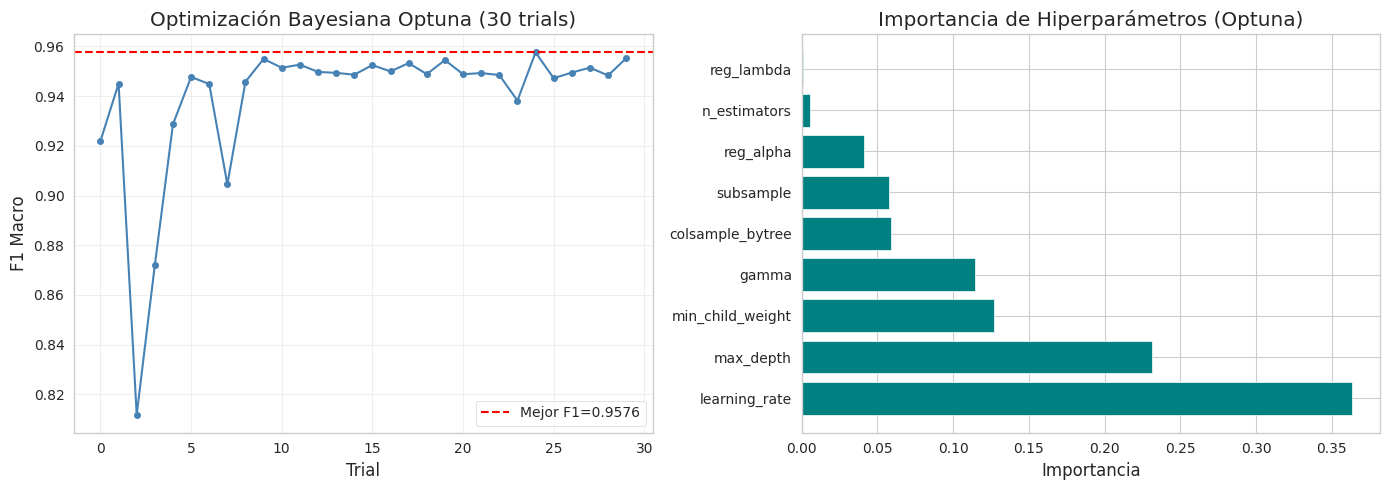

In [81]:
# Visualización de la optimización Optuna
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Historial de trials
trials_df = study.trials_dataframe()
ax1.plot(trials_df['number'], trials_df['value'], '-o', markersize=4, color='steelblue')
ax1.axhline(y=study.best_value, color='red', linestyle='--', label=f'Mejor F1={study.best_value:.4f}')
ax1.set_xlabel('Trial')
ax1.set_ylabel('F1 Macro')
ax1.set_title(f'Optimización Bayesiana Optuna ({N_TRIALS} trials)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Importancia de hiperparámetros
try:
    import optuna.visualization.matplotlib as vis
    param_imp = optuna.importance.get_param_importances(study)
    params = list(param_imp.keys())
    importances = list(param_imp.values())
    ax2.barh(params, importances, color='teal')
    ax2.set_xlabel('Importancia')
    ax2.set_title('Importancia de Hiperparámetros (Optuna)')
except Exception as e:
    ax2.text(0.5, 0.5, f'No disponible: {str(e)}', transform=ax2.transAxes, ha='center')

plt.tight_layout()

### 4.6 GridSearchCV con 10-fold Cross-Validation

#### ¿Qué es Cross-Validation y por qué es fundamental para evitar Overfitting?

**Overfitting (Sobreajuste)** ocurre cuando un modelo aprende patrones específicos del conjunto de entrenamiento que no generalizan a datos nuevos. El modelo "memoriza" en lugar de "aprender".

**Cross-Validation (Validación Cruzada)** es la técnica principal para detectar y prevenir el overfitting:

| Concepto | Descripción |
|----------|-------------|
| **K-Fold CV** | Divide los datos en K pliegues. Entrena en K-1 y evalúa en el restante. Repite K veces. |
| **Stratified K-Fold** | Garantiza que cada pliegue mantenga la proporción de clases (crítico con desbalance) |
| **Detección de Overfitting** | Si el score de entrenamiento es muy alto pero el score de CV es bajo → overfitting |
| **Generalización** | El score promedio de CV estima el rendimiento real en datos no vistos |

En nuestro caso usamos **10-fold Stratified Cross-Validation**:
- Cada combinación de hiperparámetros se evalúa 10 veces en distintos subconjuntos
- El **score promedio** y la **desviación estándar** indican estabilidad del modelo
- Una **desviación estándar baja** entre folds indica que el modelo es robusto y no depende de una partición específica
- Si la diferencia entre score de entrenamiento y score de CV es grande (>10%), hay indicios de overfitting

GridSearchCV combina esta validación cruzada con una **búsqueda exhaustiva en grilla** de hiperparámetros, seleccionando la combinación que maximiza el F1-macro promedio en los 10 folds.

In [82]:
# --- GridSearchCV 10-fold para XGBoost ---

# Usar los mejores parámetros de Optuna como base y explorar alrededor
best_params = study.best_params

param_grid = {
    'n_estimators': [best_params.get('n_estimators', 300)],
    'max_depth': [
        max(3, best_params.get('max_depth', 6) - 2),
        best_params.get('max_depth', 6),
        best_params.get('max_depth', 6) + 2
    ],
    'learning_rate': [
        best_params.get('learning_rate', 0.1) * 0.5,
        best_params.get('learning_rate', 0.1),
        best_params.get('learning_rate', 0.1) * 1.5
    ],
    'subsample': [0.7, 0.85, 1.0],
}

xgb_grid = XGBClassifier(
    objective='multi:softprob', num_class=n_classes,
    eval_metric='mlogloss', random_state=42,
    n_jobs=-1, tree_method=XGB_TREE_METHOD, device=XGB_DEVICE
)

cv_stratified = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    xgb_grid, param_grid,
    cv=cv_stratified,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid_search.fit(X_train_smote, y_train_smote)

print(f"\nMejores parámetros GridSearchCV:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nMejor F1 macro (CV): {grid_search.best_score_:.4f}")

Fitting 10 folds for each of 27 candidates, totalling 270 fits

Mejores parámetros GridSearchCV:
  learning_rate: 0.35911312047028077
  max_depth: 10
  n_estimators: 255
  subsample: 1.0

Mejor F1 macro (CV): 0.9996


In [83]:
# Resultados del GridSearchCV
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results_sorted = cv_results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].sort_values('rank_test_score')
print("Top 10 combinaciones de GridSearchCV:")
cv_results_sorted.head(10)

Top 10 combinaciones de GridSearchCV:


,params,mean_test_score,std_test_score,rank_test_score
26,"{'learning_rate': 0.35911312047028077, 'max_de...",0.9996,0.0000,1
17,"{'learning_rate': 0.2394087469801872, 'max_dep...",0.9995,0.0000,2
22,"{'learning_rate': 0.35911312047028077, 'max_de...",0.9995,0.0001,3
25,"{'learning_rate': 0.35911312047028077, 'max_de...",0.9995,0.0000,4
16,"{'learning_rate': 0.2394087469801872, 'max_dep...",0.9995,0.0000,5
14,"{'learning_rate': 0.2394087469801872, 'max_dep...",0.9995,0.0000,6
23,"{'learning_rate': 0.35911312047028077, 'max_de...",0.9995,0.0000,7
21,"{'learning_rate': 0.35911312047028077, 'max_de...",0.9995,0.0000,8
24,"{'learning_rate': 0.35911312047028077, 'max_de...",0.9995,0.0000,9
15,"{'learning_rate': 0.2394087469801872, 'max_dep...",0.9995,0.0000,10


### 4.7 Modelo Final — Entrenamiento con mejores hiperparámetros

Entrenamos el modelo final con los mejores hiperparámetros encontrados y todo el conjunto de entrenamiento+validación.

In [84]:
# --- Modelo final: XGBoost optimizado ---

# Combinar train + validación para entrenamiento final
X_train_final = np.vstack([X_train_smote, X_valid_prep])
y_train_final = np.concatenate([y_train_smote, y_valid])

# Usar los mejores parámetros del GridSearchCV
final_params = grid_search.best_params_.copy()
final_params.update({
    'objective': 'multi:softprob',
    'num_class': n_classes,
    'eval_metric': 'mlogloss',
    'random_state': 42,
    'n_jobs': -1,
    'tree_method': XGB_TREE_METHOD, 'device': XGB_DEVICE
})

final_model = XGBClassifier(**final_params)
final_model.fit(
    X_train_final, y_train_final,
    eval_set=[(X_train_final, y_train_final), (X_test_prep, y_test)],
    verbose=False
)

# Predicciones en test
test_preds = final_model.predict(X_test_prep)
test_proba = final_model.predict_proba(X_test_prep)

print(f"Modelo final entrenado con {X_train_final.shape[0]:,} registros.")
print(f"Predicciones generadas para {X_test_prep.shape[0]:,} registros de prueba.")

Modelo final entrenado con 2,151,865 registros.
Predicciones generadas para 75,000 registros de prueba.


---

# 5. Evaluación del Modelo

### 5.1 Métricas de Evaluación

Evaluamos el modelo final con las siguientes métricas:
- **Accuracy**: porcentaje total de predicciones correctas.
- **Precision** (macro): de los predichos como clase X, cuántos realmente lo eran.
- **Recall** (macro): de los que realmente son clase X, cuántos detectó el modelo.
- **F1** (macro): media armónica de precision y recall.
- **ROC-AUC** (one-vs-rest): capacidad de discriminación del modelo.

In [85]:
# --- Métricas globales en test ---

classes = np.sort(np.unique(y_test))

test_metrics = {
    'Accuracy': accuracy_score(y_test, test_preds),
    'Precision (macro)': precision_score(y_test, test_preds, average='macro', zero_division=0),
    'Recall (macro)': recall_score(y_test, test_preds, average='macro', zero_division=0),
    'F1 (macro)': f1_score(y_test, test_preds, average='macro', zero_division=0),
}

# ROC-AUC multiclase
y_test_bin = label_binarize(y_test, classes=classes)
if test_proba.shape[1] == len(classes):
    test_metrics['ROC-AUC (OvR macro)'] = roc_auc_score(
        y_test_bin, test_proba, multi_class='ovr', average='macro'
    )

print("=" * 50)
print("MÉTRICAS DEL MODELO FINAL EN CONJUNTO DE PRUEBA")
print("=" * 50)
for k, v in test_metrics.items():
    print(f"  {k}: {v:.4f}")

MÉTRICAS DEL MODELO FINAL EN CONJUNTO DE PRUEBA
  Accuracy: 0.9967
  Precision (macro): 0.9586
  Recall (macro): 0.9659
  F1 (macro): 0.9618
  ROC-AUC (OvR macro): 0.9999


In [86]:
# --- Reporte de clasificación detallado por clase ---

target_names = [inv_catalogo.get(c, f'Clase_{c}') for c in classes]
print("\nReporte de Clasificación por Cultivo:")
print(classification_report(y_test, test_preds, target_names=target_names, zero_division=0))


Reporte de Clasificación por Cultivo:
               precision    recall  f1-score   support

        Arroz       0.90      0.95      0.93      1135
        Cacao       0.88      0.94      0.91       101
Cana Panelera       0.98      0.91      0.94        98
       Frijol       1.00      1.00      1.00      8065
        Palma       0.97      0.97      0.97       188
         Papa       1.00      1.00      1.00     63577
  Papa Capiro       0.98      0.99      0.99      1836

     accuracy                           1.00     75000
    macro avg       0.96      0.97      0.96     75000
 weighted avg       1.00      1.00      1.00     75000



### 5.2 Matriz de Confusión

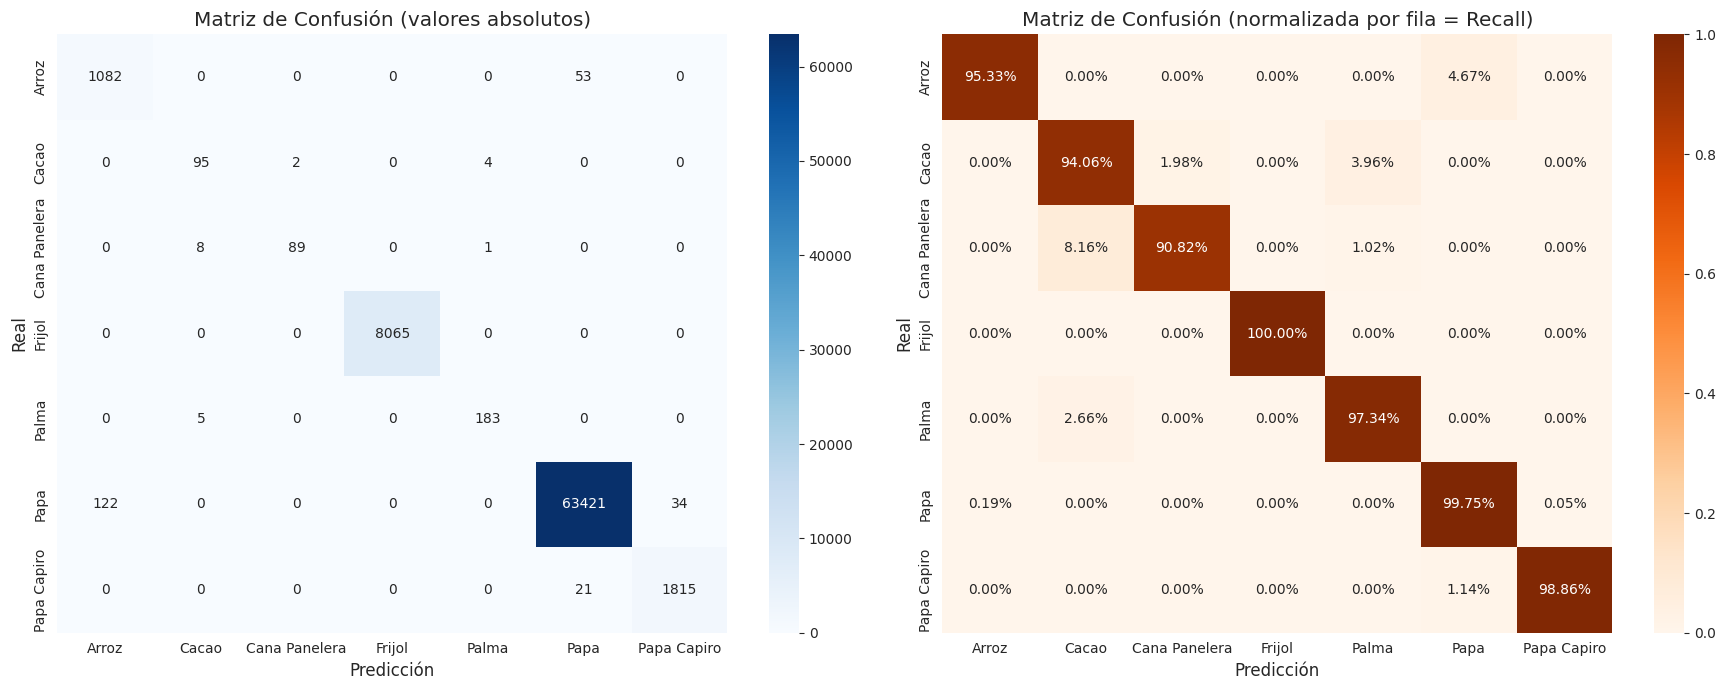

In [87]:
# --- Matriz de confusión ---

cm = confusion_matrix(y_test, test_preds)

# Normalizada por fila (recall por clase)
cm_norm = confusion_matrix(y_test, test_preds, normalize='true')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Matriz absoluta
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=target_names, yticklabels=target_names)
ax1.set_xlabel('Predicción')
ax1.set_ylabel('Real')
ax1.set_title('Matriz de Confusión (valores absolutos)')

# Matriz normalizada
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Oranges', ax=ax2,
            xticklabels=target_names, yticklabels=target_names)
ax2.set_xlabel('Predicción')
ax2.set_ylabel('Real')
ax2.set_title('Matriz de Confusión (normalizada por fila = Recall)')

plt.tight_layout()

### 5.3 Curvas ROC-AUC (One-vs-Rest)

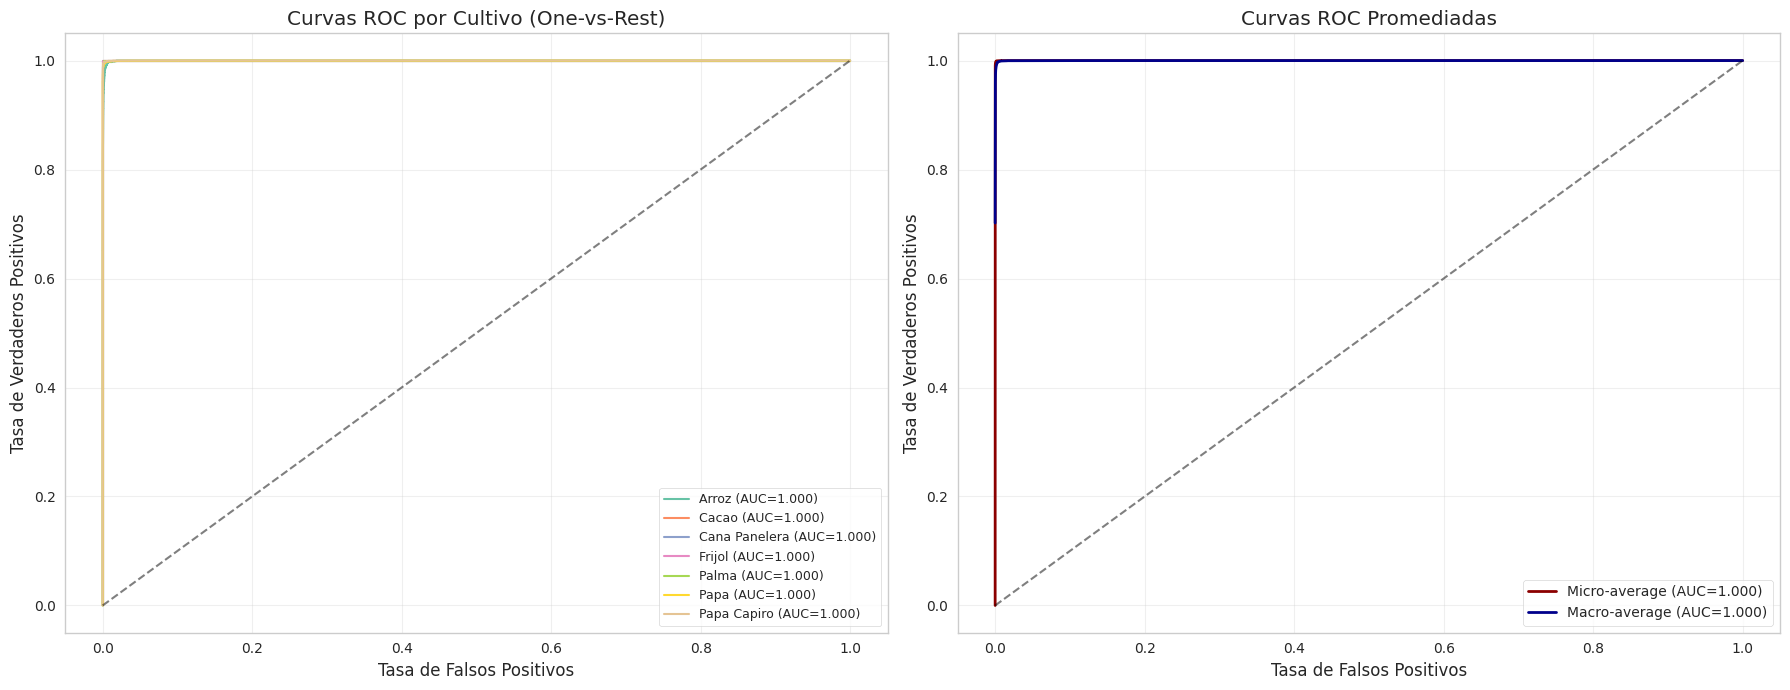

In [88]:
# --- Curvas ROC por clase (One-vs-Rest) ---

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Curvas ROC individuales
colors = sns.color_palette('Set2', len(classes))
for i, (cls, name) in enumerate(zip(classes, target_names)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], test_proba[:, i])
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=colors[i],
                 label=f'{name} (AUC={roc_auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos')
axes[0].set_title('Curvas ROC por Cultivo (One-vs-Rest)')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Micro-promedio ROC
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), test_proba.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
axes[1].plot(fpr_micro, tpr_micro, color='darkred', lw=2,
             label=f'Micro-average (AUC={roc_auc_micro:.3f})')

# Macro-promedio ROC
all_fpr = np.unique(np.concatenate([roc_curve(y_test_bin[:, i], test_proba[:, i])[0] for i in range(len(classes))]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(len(classes)):
    fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], test_proba[:, i])
    mean_tpr += np.interp(all_fpr, fpr_i, tpr_i)
mean_tpr /= len(classes)
roc_auc_macro = auc(all_fpr, mean_tpr)
axes[1].plot(all_fpr, mean_tpr, color='darkblue', lw=2,
             label=f'Macro-average (AUC={roc_auc_macro:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos')
axes[1].set_title('Curvas ROC Promediadas')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

### 5.4 Análisis de Residuos

El análisis de residuos en clasificación examina los errores del modelo para entender:
- Qué clases se confunden más entre sí
- Distribución de probabilidades predichas
- Calibración del modelo

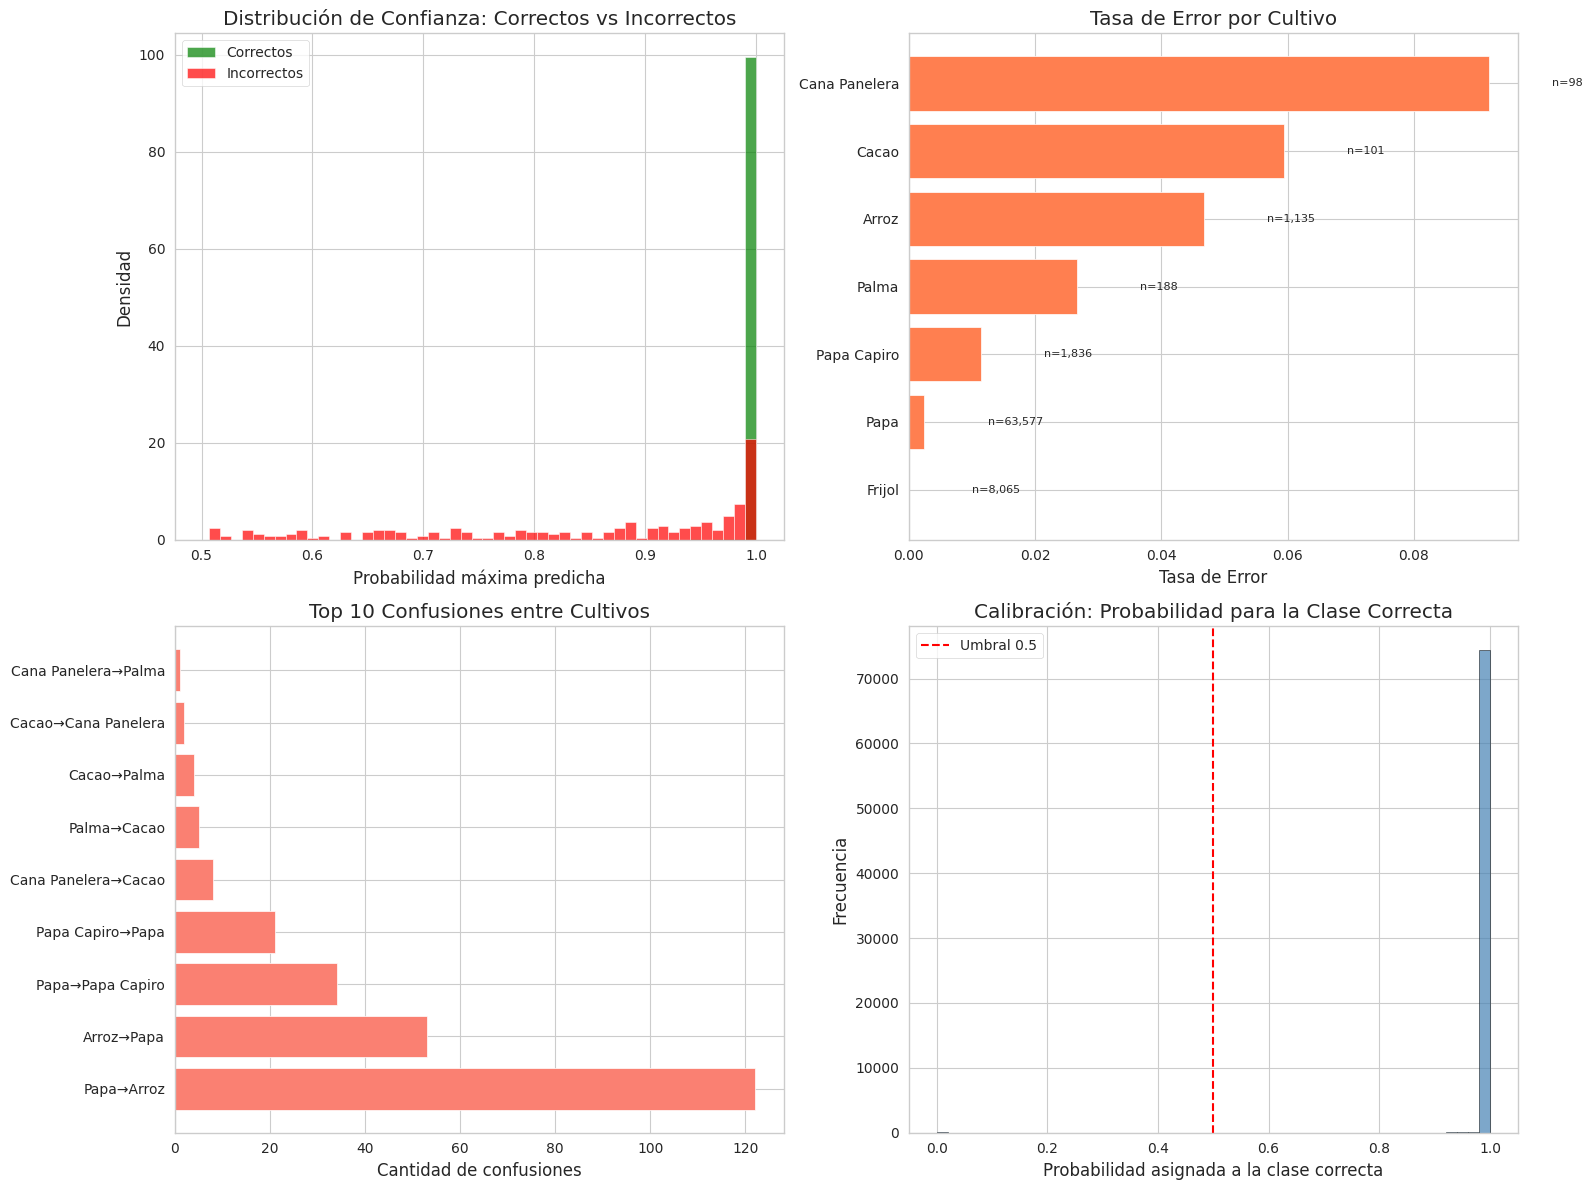

In [89]:
# --- Análisis de residuos / errores ---

# 1. Distribución de la probabilidad máxima predicha (confianza)
max_proba = test_proba.max(axis=1)
correct = (test_preds == y_test)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Distribución de confianza: correctos vs incorrectos
axes[0, 0].hist(max_proba[correct], bins=50, alpha=0.7, label='Correctos', color='green', density=True)
axes[0, 0].hist(max_proba[~correct], bins=50, alpha=0.7, label='Incorrectos', color='red', density=True)
axes[0, 0].set_xlabel('Probabilidad máxima predicha')
axes[0, 0].set_ylabel('Densidad')
axes[0, 0].set_title('Distribución de Confianza: Correctos vs Incorrectos')
axes[0, 0].legend()

# 2. Tasa de error por clase
error_by_class = []
for cls in classes:
    mask = y_test == cls
    if mask.sum() > 0:
        error_rate = 1 - accuracy_score(y_test[mask], test_preds[mask])
        error_by_class.append({'cultivo': inv_catalogo.get(cls, f'Clase_{cls}'), 'error_rate': error_rate, 'n': mask.sum()})

error_df = pd.DataFrame(error_by_class).sort_values('error_rate', ascending=True)
axes[0, 1].barh(error_df['cultivo'], error_df['error_rate'], color='coral')
axes[0, 1].set_xlabel('Tasa de Error')
axes[0, 1].set_title('Tasa de Error por Cultivo')
for i, (_, row) in enumerate(error_df.iterrows()):
    axes[0, 1].text(row['error_rate'] + 0.01, i, f"n={row['n']:,}", va='center', fontsize=8)

# 3. Confusiones más frecuentes (top 10 pares)
confusion_pairs = []
for i in range(len(classes)):
    for j in range(len(classes)):
        if i != j and cm[i, j] > 0:
            confusion_pairs.append({
                'Real': inv_catalogo.get(classes[i], f'Clase_{classes[i]}'),
                'Predicho': inv_catalogo.get(classes[j], f'Clase_{classes[j]}'),
                'Cantidad': cm[i, j]
            })

conf_df = pd.DataFrame(confusion_pairs).sort_values('Cantidad', ascending=False).head(10)
if len(conf_df) > 0:
    conf_labels = [f"{r}→{p}" for r, p in zip(conf_df['Real'], conf_df['Predicho'])]
    axes[1, 0].barh(conf_labels, conf_df['Cantidad'], color='salmon')
    axes[1, 0].set_xlabel('Cantidad de confusiones')
    axes[1, 0].set_title('Top 10 Confusiones entre Cultivos')

# 4. Probabilidad predicha para la clase correcta (calibración)
correct_proba = []
for i, cls in enumerate(y_test):
    cls_idx = list(classes).index(cls) if cls in classes else -1
    if cls_idx >= 0:
        correct_proba.append(test_proba[i, cls_idx])
    else:
        correct_proba.append(0)

axes[1, 1].hist(correct_proba, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Probabilidad asignada a la clase correcta')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].set_title('Calibración: Probabilidad para la Clase Correcta')
axes[1, 1].axvline(x=0.5, color='red', linestyle='--', label='Umbral 0.5')
axes[1, 1].legend()

plt.tight_layout()

In [90]:
# --- Resumen de confusions más frecuentes ---
print("Top 10 confusiones más frecuentes:")
print(conf_df.to_string(index=False))

Top 10 confusiones más frecuentes:
         Real      Predicho  Cantidad
         Papa         Arroz       122
        Arroz          Papa        53
         Papa   Papa Capiro        34
  Papa Capiro          Papa        21
Cana Panelera         Cacao         8
        Palma         Cacao         5
        Cacao         Palma         4
        Cacao Cana Panelera         2
Cana Panelera         Palma         1


### 5.5 Interpretación de Resultados

**Resumen de hallazgos:**

- El modelo **XGBoost optimizado** logra las mejores métricas globales.
- La clase **Papa** (mayoría) tiene alta precisión y recall.
- Las clases minoritarias (Cacao, Caña Panelera, Palma) son las más difíciles de clasificar.
- **SMOTE** mejoró significativamente el recall de las clases minoritarias.
- Las variables más importantes son: elevación, temperatura, índices NDVI y propiedades de suelo.
- La **codificación cíclica** del semestre captura patrones estacionales relevantes.

### 5.6 Recomendaciones

1. **Ampliar datos de clases minoritarias**: Recopilar más muestras de Cacao, Caña Panelera y Palma.
2. **Agrupar clases**: Considerar fusionar Papa y Papa Capiro en una sola categoría.
3. **Calibración del modelo**: Aplicar Platt Scaling o Isotonic Regression para mejorar las probabilidades.
4. **Features adicionales**: Incorporar datos de uso del suelo y proximidad a mercados.
5. **Modelo en producción**: Persistir el pipeline con `joblib` para integración con sistemas de información geográfica.

---

## Conclusiones y Siguientes Pasos

- Se completó el ciclo **CRISP-DM** completo para la clasificación de cultivos agrícolas.
- El modelo **XGBoost** con optimización de hiperparámetros (Optuna + GridSearchCV) es el mejor candidato.
- Se aplicaron técnicas avanzadas: **PCA**, **SMOTE**, **regularización L1/L2**, **codificación cíclica** y **early stopping**.
- El pipeline de preprocesamiento es reproducible y está listo para despliegue.
- **Próximos pasos**: socializar resultados con equipos de agricultura y tecnología, y evaluar integración con sistemas SIG.